# UFC PREDICTION ALGORITHM

##### A project made by Giovanni Ditaranto 

Decision Science 2025/26 Uniba

## 🔧 Bug-Fix Changelog

| Version | Cell(s) | Bug | Fix |
|---|---|---|---|
| v1-fix-1 | cell2 | `parse_height` silent NaN on `5'11"` | Try both `"' "` and `"'"` separators |
| v1-fix-2 | cell3 | Global `fillna(0)` contaminated future rows | Removed; zero-fill only inside `extract_features` for debuts |
| v1-fix-3 | cell4/5 | `global_stats` used future data for normalization | Reset & updated inside loop, after feature extraction |
| v1-fix-4 | cell5 | Duplicate fallback loop guard in cell6 | Removed; `run_feature_engine()` is the single source of truth |
| v1-fix-5 | cell9 | Red corner bias — model learned corner position | Dataset symmetrized: each fight duplicated with r/b swapped |
| v1-fix-6 | cell9 | No clean binary target; Draws/NCs leaked into ML set | Explicit `target` column; Draws/NCs dropped |
| v1-fix-7 | cell10 | Random 80/20 split leaked future fights into training | Strict date split at 2024-01-01 |
| v1-fix-8 | cell12/14d | No ELO baseline comparison | ELO baseline added to all evaluation tables |
| v1-fix-9 | cell12b | Feature importance crash (length mismatch) | Index pulled from `feature_names_in_` |
| v1-fix-10 | cell12c | `baseline_acc` undefined at print time | Both baselines computed locally before comparison table |
| v1-fix-11 | cell15a/17 | `model_df_2005` stale reference after symmetrization | Replaced with `sym_df_2005` throughout |
| **v2-fix-1** | **cell14a, cell15a, cell17, cell12b** | **`ValueError: Shape (13774, 151) vs (13774, 161)` — `SimpleImputer` silently drops all-NaN columns, making output narrower than the column list passed to `pd.DataFrame()`** | **Drop all-NaN columns before imputation; use `imputer.feature_names_in_` as authoritative column list; align val to train columns with `.reindex()`; added `assert` guards** |
| **v2-fix-2** | **cell17, cell18** | **`ValueError: 10 columns passed, data had 8 columns` — rolling window imputer drops all-NaN columns per window so each model may have fewer features than `available`; `coeff_df` and `predict_advantages` then pass the full `available` list causing shape crash** | **Store `window_features[i]` per window; build `coeff_df` by dict-zipping each model's own feature list (filling missing with 0); cell18 builds `X_row` with `.reindex(columns=this_feats)` and loops `coef_` over `this_feats` only** |


In [205]:
# !pip install jupyter_contrib_nbextensions
# !jupyter contrib nbextension install --user
# !jupyter nbextension enable python-markdown/main

# %%

### Loading the datasets and checking on them

In [206]:
import pandas as pd
import numpy as np
fights    = pd.read_csv('data/ufc_fight_results.csv')
stats     = pd.read_csv('data/ufc_fight_stats.csv')
details   = pd.read_csv('data/ufc_fighter_details.csv')
tott      = pd.read_csv('data/ufc_fighter_tott.csv')
events    = pd.read_csv('data/ufc_event_details.csv')

In [207]:
fights.head(2)

,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
0,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,W/L,Featherweight Bout,Decision - Unanimous,5,5:00,5 Rnd (5-5-5-5-5),Chris Tognoni,Eric Colon 45 - 50.David Lethaby 45 - 50.Sal D...,http://ufcstats.com/fight-details/e4aa60812489...
1,UFC Fight Night: Allen vs. Costa,Dooho Choi vs. Daniel Santos,W/L,Featherweight Bout,KO/TKO,2,4:29,3 Rnd (5-5-5),Kerry Hatley,Punch to Body At Distance,http://ufcstats.com/fight-details/fc1266e2892e...


In [208]:
events.head(2)

,EVENT,URL,DATE,LOCATION
0,UFC Fight Night: Allen vs. Costa,http://ufcstats.com/event-details/73abb7a5c57f...,"May 16, 2026","Las Vegas, Nevada, USA"
1,UFC 328: Chimaev vs. Strickland,http://ufcstats.com/event-details/9eedac48b497...,"May 09, 2026","Newark, New Jersey, USA"


In [209]:
details.head(2)

,FIRST,LAST,NICKNAME,URL
0,Tom,Aaron,NaN,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny,Abbadi,The Assassin,http://ufcstats.com/fighter-details/15df64c02b...


In [210]:
tott.head(2)

,FIGHTER,HEIGHT,WEIGHT,REACH,STANCE,DOB,URL
0,Tom Aaron,--,155 lbs.,--,NaN,"Jul 13, 1978",http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,--,Orthodox,"Jul 03, 1983",http://ufcstats.com/fighter-details/15df64c02b...


In [211]:
print(f'fights columns: {fights.columns.tolist()}')
print(f'stats columns: {stats.columns.tolist()}')
print(f'events columns:{events.columns.tolist()}')
print(f'details columns: {details.columns.tolist()}')
print(f'tott columns: {tott.columns.tolist()}')
        

fights columns: ['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']
stats columns: ['EVENT', 'BOUT', 'ROUND', 'FIGHTER', 'KD', 'SIG.STR.', 'SIG.STR. %', 'TOTAL STR.', 'TD', 'TD %', 'SUB.ATT', 'REV.', 'CTRL', 'HEAD', 'BODY', 'LEG', 'DISTANCE', 'CLINCH', 'GROUND']
events columns:['EVENT', 'URL', 'DATE', 'LOCATION']
details columns: ['FIRST', 'LAST', 'NICKNAME', 'URL']
tott columns: ['FIGHTER', 'HEIGHT', 'WEIGHT', 'REACH', 'STANCE', 'DOB', 'URL']


# UFC PREDICTION
I scraped ufcstats.com for data, and got 5 datasets:
- Fights -> one row for every fight in an event (fight night) - with results (W/L or L/W) and method of finish + duration time and number of rounds 
- Stats -> for every round in a fight we have stats on how the fight went

- Details -> Nickname of the fighters, could be useful for merging w/ other datsets

- tott -> For every fighter we have a row w/ height, weight, reach and stance and date of birth

- Events -> one row for every event (fight nights) and date of the event

Now before joining them in a unique dataset I will check for NaN, problems or incongruence in names, since fighters don't have a unique ID, so I can't be certain.

After The join I will aggregate some columns to make features that will makes sense for the predictive algorithm, and will calculate some aggregated features



###  Before the JOIN

Data check and cleaning

In [212]:
# Check the latest and earliest events
print("Latest event:", events["DATE"].max())
print("Earliest event:", events["DATE"].min())

# Fixing the data type of the date column
print('Date column dtype: ')
events["DATE"].dtype
events["DATE"] = pd.to_datetime(events["DATE"], format="mixed")
print(events["DATE"].dtype)   # Should now be datetime64[ns]
print("Latest event:", events["DATE"].max())
print("Earliest event:", events["DATE"].min())


Latest event: September 29, 2012
Earliest event: April 01, 2009
Date column dtype: 
datetime64[ns]
Latest event: 2026-05-16 00:00:00
Earliest event: 1994-03-11 00:00:00


In [213]:
# print(f'nulli  fake: {(events == "---").sum()}')
# print(f'nulli  fake: {(fights == "---").sum()}')
# print(f'nulli  fake: {(stats == "---").sum()}')
# print(f'nulli  fake: {(details == "---").sum()}')
# print(f'nulli  fake: {(tott == "---").sum()}')

#REPLACING NULLI FAKES WITH NAN
events = events.replace("---", np.nan)
fights = fights.replace("---", np.nan)
stats = stats.replace("---", np.nan)
details = details.replace("---", np.nan)
tott = tott.replace("---", np.nan)


In [214]:
# CHECK FOR NAMES INCONGRUENCIES
listfighter = stats['FIGHTER'].value_counts()
print(listfighter)
    

FIGHTER
Rafael Dos Anjos    112
Max Holloway        111
Jim Miller          104
Frankie Edgar        99
Andrei Arlovski      95
                   ... 
Scott Fiedler         1
John Campetella       1
Julian Sanchez        1
Reza Nasri            1
Thomas Ramirez        1
Name: count, Length: 2678, dtype: int64


In [215]:
# null rate x Column
print(f'Null rate by column in events:\n{events.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in fights:\n{fights.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in stats:\n{stats.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in details:\n{details.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in tott:\n{tott.isna().mean().sort_values(ascending=False)}')

# events.isna().sum()[events.isna().sum() > 0]

# events.columns[events.isna().any()].tolist()



Null rate by column in events:
EVENT       0.0
URL         0.0
DATE        0.0
LOCATION    0.0
dtype: float64

Null rate by column in fights:
DETAILS        0.008964
REFEREE        0.002988
EVENT          0.000000
OUTCOME        0.000000
BOUT           0.000000
WEIGHTCLASS    0.000000
METHOD         0.000000
TIME           0.000000
ROUND          0.000000
TIME FORMAT    0.000000
URL            0.000000
dtype: float64

Null rate by column in stats:
TD %          0.465657
SIG.STR. %    0.006073
ROUND         0.001024
REV.          0.001024
CTRL          0.001024
KD            0.001024
FIGHTER       0.001024
SIG.STR.      0.001024
TOTAL STR.    0.001024
TD            0.001024
SUB.ATT       0.001024
LEG           0.001024
DISTANCE      0.001024
HEAD          0.001024
BODY          0.001024
CLINCH        0.001024
GROUND        0.001024
BOUT          0.000000
EVENT         0.000000
dtype: float64

Null rate by column in details:
NICKNAME    0.446274
FIRST       0.003782
LAST        0.000000


In [216]:
# for i in tott.columns['STANCE']:
#     print(i)


In [217]:
events.isna().mean().sort_values(ascending=False)


EVENT       0.0
URL         0.0
DATE        0.0
LOCATION    0.0
dtype: float64

In [218]:
tott.isna().mean().sort_values(ascending=False)


STANCE     0.202402
HEIGHT     0.000000
FIGHTER    0.000000
WEIGHT     0.000000
REACH      0.000000
DOB        0.000000
URL        0.000000
dtype: float64

In [219]:
details.isna().mean().sort_values(ascending=False)


NICKNAME    0.446274
FIRST       0.003782
LAST        0.000000
URL         0.000000
dtype: float64

In [220]:
stats.isna().mean().sort_values(ascending=False)


TD %          0.465657
SIG.STR. %    0.006073
ROUND         0.001024
REV.          0.001024
CTRL          0.001024
KD            0.001024
FIGHTER       0.001024
SIG.STR.      0.001024
TOTAL STR.    0.001024
TD            0.001024
SUB.ATT       0.001024
LEG           0.001024
DISTANCE      0.001024
HEAD          0.001024
BODY          0.001024
CLINCH        0.001024
GROUND        0.001024
BOUT          0.000000
EVENT         0.000000
dtype: float64

### |FIRST JOIN|

Join by fight id: master_df with columns [fight_id, date, fighter_r, fighter_b, winner], one row per fight.

fighter_r / fighter_b → split BOUT on " vs. " → first name = fighter_r (red corner), second = fighter_b (blue corner)
winner → 
- W/L → fighter_r won
- L/W → fighter_b won  
- D/D → "Draw"
- NC/NC → "No Contest"


 date → merge fights with events on EVENT (after stripping whitespace) → take DATE

In [221]:
# JOIN INTO master_df
# Strip whitespace from EVENT for clean merge
fights['EVENT'] = fights['EVENT'].str.strip()
events['EVENT'] = events['EVENT'].str.strip()

# Merge fights with events to get DATE
master_df = fights.merge(events[['EVENT', 'DATE']], on='EVENT', how='left')

# Parse BOUT to extract fighters (first = red corner, second = blue corner)
master_df[['fighter_r', 'fighter_b']] = master_df['BOUT'].str.split(' vs. ', expand=True)

# Create winner column based on OUTCOME
def get_winner(row):
    if row['OUTCOME'] == 'W/L':
        return row['fighter_r']
    elif row['OUTCOME'] == 'L/W':
        return row['fighter_b']
    elif row['OUTCOME'] == 'D/D':
        return 'Draw'
    elif row['OUTCOME'] == 'NC/NC':
        return 'No Contest'
    else:
        return None

master_df['winner'] = master_df.apply(get_winner, axis=1)

# Select and rename columns
master_df = master_df[['URL', 'DATE', 'EVENT', 'BOUT',
           'fighter_r', 'fighter_b', 'winner']].rename(columns={'URL': 'fight_id'})
print(f'master_df shape: {master_df.shape}')
print(master_df.head())
print(master_df['winner'].value_counts())


master_df shape: (8701, 7)
                                            fight_id       DATE  \
0  http://ufcstats.com/fight-details/e4aa60812489... 2026-05-16   
1  http://ufcstats.com/fight-details/fc1266e2892e... 2026-05-16   
2  http://ufcstats.com/fight-details/ecb7ff543dd4... 2026-05-16   
3  http://ufcstats.com/fight-details/57bd683efc79... 2026-05-16   
4  http://ufcstats.com/fight-details/a6ec8573a9d3... 2026-05-16   

                              EVENT                                      BOUT  \
0  UFC Fight Night: Allen vs. Costa         Arnold Allen vs. Melquizael Costa   
1  UFC Fight Night: Allen vs. Costa              Dooho Choi vs. Daniel Santos   
2  UFC Fight Night: Allen vs. Costa           Malcolm Wellmaker vs. Juan Diaz   
3  UFC Fight Night: Allen vs. Costa  Modestas Bukauskas vs. Christian Edwards   
4  UFC Fight Night: Allen vs. Costa            Timmy Cuamba vs. Benardo Sopaj   

            fighter_r          fighter_b              winner  
0        Arnold Alle

# Features Engineering on master_df

**ELO calculation**(per fight, in order):
$$expected_r = 1 / (1 + 10**((elo_b - elo_r) / 400))$$
$$expected_b = 1 - expected_r$$
$$new_elo_r = elo_r + K * (actual_r - expected_r)$$

$$actual_r = \begin{cases}\begin{alignat*} {4} 1&  &if &wins, \\&0.5 &if &draws, \\&0 &if &loses\end{alignat*}\end{cases}$$


| Category | Features | Source |
|---|---|---|
| **Career cumulative** | `num_fights`, `wins`, `losses`, `win_rate` | master_df |
| **Striking** | avg sig strikes landed/attempted per fight, avg KD, accuracy, head/body/leg ratio | stats |
| **Grappling** | avg TD landed/attempted, TD accuracy, avg control time, avg sub attempts, avg reversals | stats |
| **Striking defense** | avg opponent sig strikes absorbed per fight, striking defense % | stats (opponent) |
| **Grappling defense** | avg opponent TD per fight, TD defense % | stats (opponent) |
| **ELO** | rating (start 1500, K=32), expected score, rating change | computed per fight |
| **Opponent quality** | avg opponent ELO faced, avg opponent win rate | computed |
| **Recency** | days since last fight, fights in last 365d | master_df |
| **Rolling form (last 3/5)** | avg sig strikes, avg control time, finish rate in last N fights | computed |
| **Physical** | height, weight, reach, stance, age at fight time | tott + fight date |
| **Finish rate** | % of wins by KO/TKO, % by submission | fights (METHOD) |


than

| Category | Features | Source | How to calculate |
|---|---|---|---|
| **Opponent-adjusted striking** | striking score × opponent's striking defense weight | `stats` (opponent's sig strikes landed/attempted across their career) | Track each fighter's **striking defense** = `1 - (sig strikes absorbed / sig strikes faced)`. For fighter A's striking score: `A_sig_landed_per_fight × (1 + opp_striking_defense / avg_striking_defense)` — inflates when they perform against good defenders, deflates vs poor defenders |
| **Opponent-adjusted grappling** | TD score × opponent's TD defense weight | `stats` (opponent's TD landed/attempted across their career) | Track each fighter's **TD defense** = `1 - (opp_TD_landed / opp_TD_attempted)`. Same adjustment formula as striking |
| **Opponent ELO quality** | avg ELO, max ELO, min ELO of opponents faced | `master_df` ELO (computed chronologically) | For each fighter, track list of opponent ELOs faced. Pre-fight feature = `mean(opponent_elos)`, `max(opponent_elos)`, etc. |
| **Stance matchup** | same_stance, fighter_is_southpaw | `tott['STANCE']` (Orthodox/Southpaw/Switch/NaN) | Parse stance for both fighters. Flags: `same_stance` (1 if both same), `fighter_r_southpaw` (1 if fighter_r is southpaw). Southpaw vs orthodox gives a statistical edge |
| **Reach advantage** | reach_diff, reach_ratio | `tott['REACH']` (inches as string like `"72"`, `"--"`) | Parse `"--"` as NaN, convert to float. `reach_diff = fighter_r_reach - fighter_b_reach`. Same for height (`5' 11"` → 71 inches) |
| **Height advantage** | height_diff, height_ratio | `tott['HEIGHT']` (feet'inches string like `"5' 11\""`, `"--"`) | Parse `"5' 11\""` → total inches. `height_diff = r_height - b_height` |
| **Recent form (last 3/5)** | weighted avg sig strikes, TD, control time, finish rate over last N fights | `stats` + `fights['METHOD']` | Exponential or linear decay weights: `w = [0.5, 0.3, 0.2]` for last 3. Sum(stat × w) for each stat. Separate features for recent KO rate, recent sub rate |
| **Weight class change** | weight_class_changed, num_weight_class_changes | `fights['WEIGHTCLASS']` | Track fighter's previous fight's weight class. Flag = 1 if `current_wc != prev_wc`. Accumulate total changes over career |
| **Championship rounds** | num_championship_round_fights, pct_fights_to_round_4+ | `fights['ROUND']` (the round the fight ended in) + `fights['TIME FORMAT']` (e.g., `"5 Rnd (5-5-5-5-5)"`) | Count fights where `ROUND >= 4` or `TIME FORMAT` indicates 5-round main event. Shows experience in deep waters |


## Step 1: Parse & Clean Stats Table


**What:** Convert `stats` from per-round raw format into per-fighter-per-fight aggregates.


```python
# For each (EVENT, BOUT, FIGHTER) group — sum rounds together
# Unpack "X of Y" columns → landed, attempted, accuracy
# Unpack "M:SS" CTRL → total seconds
```

**Columns to parse:**
| Raw column | Parse as | Output columns |
|---|---|---|
| `SIG.STR.` (e.g. `"9 of 9"`) | split on `" of "` | `sig_landed`, `sig_attempted`, `sig_acc` |
| `TOTAL STR.` | split on `" of "` | `total_landed`, `total_attempted` |
| `HEAD`, `BODY`, `LEG` | split on `" of "` | `head_landed`, `body_landed`, `leg_landed` |
| `DISTANCE`, `CLINCH`, `GROUND` | split on `" of "` | `dist_landed`, `clinch_landed`, `ground_landed` |
| `TD` | split on `" of "` | `td_landed`, `td_attempted`, `td_acc` |
| `CTRL` | `"M:SS"` → seconds | `ctrl_sec` |
| `KD`, `SUB.ATT`, `REV.` | already float | kept as-is |
| `SIG.STR. %`, `TD %` | strip `"%"`, or drop (redundant with landed/attempted) | dropped |

**Output:** `fighter_fights` table — one row per (EVENT, BOUT, FIGHTER), with summed per-fight stats.

Then merge with `master_df` to get date + outcome per fighter:
```
fighter_fights = fighter_fights.merge(
    master_df[['fight_id', 'event', 'bout', 'date', 'fighter_r', 'fighter_b', 'winner']],
    on=['event', 'bout']
)
```

Also parse `tott` for static fighter info:
- `HEIGHT`: `"5' 11""` → total inches (or NaN)
- `WEIGHT`: `"155 lbs."` → int (strip `" lbs."`)
- `REACH`: `"72"` → int (or NaN for `"--"`)
- `STANCE`: keep as string (Orthodox/Southpaw/Switch)
- `DOB`: parse to datetime → compute age at fight date

Parse `fights['WEIGHTCLASS']` for weight class change tracking.

---


In [222]:
# ============================================================
# CELL 1: Parse & Clean Stats Table
# Unpack "X of Y" and "M:SS" formats, sum per (fight, fighter)
# ============================================================

def parse_x_of_y(series):
    split = series.str.split(' of ', expand=True)
    return pd.to_numeric(split[0], errors='coerce'), pd.to_numeric(split[1], errors='coerce')

def parse_ctrl(series):
    split = series.str.split(':', expand=True)
    minutes = pd.to_numeric(split[0], errors='coerce').fillna(0)
    seconds = pd.to_numeric(split[1], errors='coerce').fillna(0)
    return minutes * 60 + seconds

# Map raw stat columns to clean prefixes
col_map = {
    'SIG.STR.': 'sig', 'TOTAL STR.': 'total_str',
    'HEAD': 'head', 'BODY': 'body', 'LEG': 'leg',
    'DISTANCE': 'distance', 'CLINCH': 'clinch', 'GROUND': 'ground',
    'TD': 'td',
}

stats_clean = stats.copy()
for raw_col, prefix in col_map.items():
    landed, attempted = parse_x_of_y(stats_clean[raw_col])
    stats_clean[f'{prefix}_landed'] = landed
    stats_clean[f'{prefix}_attempted'] = attempted

stats_clean['ctrl_sec'] = parse_ctrl(stats_clean['CTRL'])
for col in ['KD', 'SUB.ATT', 'REV.']:
    stats_clean[col] = pd.to_numeric(stats_clean[col], errors='coerce').fillna(0)

# Aggregate per (EVENT, BOUT, FIGHTER) – sum across rounds
sum_cols = [f'{p}_{s}' for p in col_map.values() for s in ('landed', 'attempted')]
sum_cols += ['ctrl_sec', 'KD', 'SUB.ATT', 'REV.']

fighter_fights = (
    stats_clean.groupby(['EVENT', 'BOUT', 'FIGHTER'], as_index=False)[sum_cols]
    .sum()
)

fighter_fights['sig_acc'] = np.where(
    fighter_fights['sig_attempted'] > 0,
    fighter_fights['sig_landed'] / fighter_fights['sig_attempted'], np.nan)
fighter_fights['td_acc'] = np.where(
    fighter_fights['td_attempted'] > 0,
    fighter_fights['td_landed'] / fighter_fights['td_attempted'], np.nan)

print(f'fighter_fights shape: {fighter_fights.shape}')
print(f'Unique fighters: {fighter_fights["FIGHTER"].nunique()}')
print(f'Unique bouts:   {fighter_fights[["EVENT","BOUT"]].drop_duplicates().shape[0]}')

fighter_fights shape: (17358, 27)
Unique fighters: 2678
Unique bouts:   8679


In [223]:
# ============================================================
# CELL 2: Parse Physicals (tott) & Fight Metadata (fights)
# FIX #5: parse_height now handles both "5' 11\"" and "5'11\"" formats
# ============================================================

tott_clean = tott.copy()

def parse_height(h):
    if pd.isna(h):
        return np.nan
    h = str(h).replace('"', '').strip()
    if h == '--':
        return np.nan
    # Try with space after apostrophe first, then without
    for sep in ("' ", "'"):
        parts = h.split(sep)
        if len(parts) == 2:
            try:
                return int(parts[0]) * 12 + int(parts[1].strip())
            except (ValueError, TypeError):
                continue
    return np.nan

tott_clean['height_inches'] = tott_clean['HEIGHT'].apply(parse_height)
tott_clean['weight_lbs']    = pd.to_numeric(
    tott_clean['WEIGHT'].str.replace(' lbs.', '', regex=False), errors='coerce')
tott_clean['reach_inches']  = pd.to_numeric(
    tott_clean['REACH'].astype(str).str.strip('"').str.strip(), errors='coerce')
tott_clean['DOB'] = pd.to_datetime(tott_clean['DOB'], format='mixed', errors='coerce')

# --- Parse fights (method categories + weight class) ---
def classify_method(m):
    if pd.isna(m):
        return np.nan
    ms = str(m).lower()
    if 'ko' in ms or 'tko' in ms: return 'KO/TKO'
    elif 'submission' in ms:       return 'SUB'
    elif 'decision' in ms:         return 'DEC'
    elif 'dq' in ms:               return 'DQ'
    else:                          return 'OTHER'

fights['method_cat']           = fights['METHOD'].apply(classify_method)
fights['weight_class']         = fights['WEIGHTCLASS'].str.replace(' Bout', '', regex=False)
fights['max_rounds']           = (fights['TIME FORMAT'].str.extract(r'(\d+) Rnd', expand=False)
                                   .astype(float).fillna(3))
fights['champ_round_possible'] = fights['max_rounds'] >= 5

print('METHOD categories:')
print(fights['method_cat'].value_counts())
print()
print('Sample weight classes:')
print(fights['weight_class'].value_counts().head(10))
print()
print(f"Height parsed (non-NaN): {tott_clean['height_inches'].notna().sum()}")


METHOD categories:
method_cat
DEC       4064
KO/TKO    2837
SUB       1685
OTHER       92
DQ          23
Name: count, dtype: int64

Sample weight classes:
weight_class
Lightweight            1402
Welterweight           1330
Middleweight           1092
Featherweight           828
Bantamweight            746
Heavyweight             711
Light Heavyweight       694
Flyweight               384
Women's Strawweight     346
Women's Flyweight       259
Name: count, dtype: int64

Height parsed (non-NaN): 4101


In [224]:
# ============================================================
# CELL 3: Build Chronological Fight–Fighter Table
# One row per (fight, fighter) with stats, physicals, metadata
# FIX #4: Removed global fillna(0) — raw stats stay NaN for missing fights.
#          Zero-filling happens only inside extract_features() for debut fighters.
# ============================================================

chrono_rows = []
for _, row in master_df.iterrows():
    for role, fighter in [('r', row['fighter_r']), ('b', row['fighter_b'])]:
        chrono_rows.append({
            'fight_id':     row['fight_id'],
            'date':         row['DATE'],
            'event':        row['EVENT'],
            'bout':         row['BOUT'],
            'fighter':      fighter,
            'role':         role,
            'opponent':     row['fighter_b'] if role == 'r' else row['fighter_r'],
            'winner_label': row['winner'],
        })

chrono = pd.DataFrame(chrono_rows)

ff = fighter_fights.rename(columns={'EVENT': 'event', 'BOUT': 'bout', 'FIGHTER': 'fighter'})
tc = tott_clean.rename(columns={'FIGHTER': 'fighter'})
fc = fights.rename(columns={'EVENT': 'event', 'BOUT': 'bout'})

chrono = chrono.merge(ff, on=['event', 'bout', 'fighter'], how='left')
chrono = chrono.merge(
    tc[['fighter', 'height_inches', 'weight_lbs', 'reach_inches', 'STANCE', 'DOB']],
    on='fighter', how='left')
chrono = chrono.merge(
    fc[['event', 'bout', 'method_cat', 'weight_class', 'champ_round_possible']],
    on=['event', 'bout'], how='left')

# FIX #4: Do NOT fillna(0) globally here.
# Stats remain NaN until extract_features handles them per-fighter.

def get_outcome(row):
    w = row['winner_label']
    if w == 'Draw':         return 'draw'
    elif w == 'No Contest': return 'no_contest'
    elif w == row['fighter']: return 'win'
    else:                   return 'loss'

chrono['outcome'] = chrono.apply(get_outcome, axis=1)
chrono = chrono.sort_values('date').reset_index(drop=True)

fight_order = (
    chrono[['fight_id', 'date']].drop_duplicates('fight_id')
    .sort_values('date').reset_index(drop=True)
)
fight_order['fight_idx'] = range(len(fight_order))
chrono = chrono.merge(fight_order, on=['fight_id', 'date'], how='left')
chrono = chrono.sort_values('fight_idx').reset_index(drop=True)

print(f'chrono shape: {chrono.shape}')
print(f'Unique fights: {chrono["fight_id"].nunique()}, rows: {len(chrono)}')
print(f'Date range: {chrono["date"].min()}  →  {chrono["date"].max()}')


chrono shape: (17454, 42)
Unique fights: 8701, rows: 17454
Date range: 1994-03-11 00:00:00  →  2026-05-16 00:00:00


In [225]:
# ============================================================
# CELL 4: Feature Engine — Functions
# FIX #3: global_stats is now initialized here and updated INSIDE the
#          chronological loop so scoring functions normalize against
#          past-only averages, never future data.
# ============================================================

CLASS_LIMITS = {
    'Flyweight': 125,
    'Bantamweight': 135,
    'Featherweight': 145,
    'Lightweight': 155,
    'Welterweight': 170,
    'Middleweight': 185,
    'Light Heavyweight': 205,
    'Heavyweight': 265,
    "Women's Strawweight": 115,
    "Women's Flyweight": 125,
    "Women's Bantamweight": 135,
    "Women's Featherweight": 145,
}

def init_fighter_history(name):
    return {
        'fighter': name,
        'num_fights': 0,
        'wins': 0, 'losses': 0, 'draws': 0,
        'ko_wins': 0, 'sub_wins': 0, 'dec_wins': 0,
        'sum_sig_landed': 0, 'sum_sig_attempted': 0,
        'sum_td_landed': 0, 'sum_td_attempted': 0,
        'sum_ctrl_sec': 0, 'sum_kd': 0, 'sum_sub_att': 0, 'sum_rev': 0,
        'sum_opp_sig_landed': 0, 'sum_opp_sig_attempted': 0,
        'sum_opp_td_landed': 0, 'sum_opp_td_attempted': 0,
        'opponent_elos': [], 'opponent_win_rates': [],
        'recent_fights': [],
        'last_fight_date': None,
        'last_weight_class': None,
        'num_weight_class_changes': 0,
        'champ_round_fights': 0,
        'sum_sig_diff': 0,
        'sum_td_diff': 0,
        'current_win_streak': 0,
        'current_loss_streak': 0,
        'last_loss_date': None,
        'sum_opp_finish_rate': 0,
        'opponent_finish_rates': [],
        'elo_finish': 1500,
        'elo': 1500,
    }

# FIX #3: reset at start of loop; updated after each fight inside the loop
global_stats = {
    'sum_sig_landed': 0, 'sum_sig_attempted': 0,
    'sum_td_landed': 0, 'sum_td_attempted': 0,
    'sum_kd': 0, 'sum_ctrl_sec': 0, 'sum_sub_att': 0,
    'total_fights': 0,
}

def global_avg(key):
    if global_stats['total_fights'] == 0:
        return 0.01
    return global_stats[key] / global_stats['total_fights']

def compute_striking_score(hist):
    n = hist['num_fights']
    if n == 0:
        return np.nan
    vol    = (hist['sum_sig_landed'] / n) / max(global_avg('sum_sig_landed'), 0.01)
    acc    = (hist['sum_sig_landed'] / max(hist['sum_sig_attempted'], 1)) / max(
              global_avg('sum_sig_landed') / max(global_avg('sum_sig_attempted'), 0.01), 0.01)
    kd     = (hist['sum_kd'] / n) / max(global_avg('sum_kd'), 0.001)
    opp    = hist['sum_opp_sig_attempted']
    if opp > 0:
        my_d   = 1 - hist['sum_opp_sig_landed'] / opp
        g_d    = 1 - global_avg('sum_sig_landed') / max(global_avg('sum_sig_attempted'), 0.01)
        d_norm = my_d / max(g_d, 0.01)
    else:
        d_norm = 1.0
    return 0.30 * vol + 0.20 * acc + 0.15 * kd + 0.35 * d_norm

def compute_grappling_score(hist):
    n = hist['num_fights']
    if n == 0:
        return np.nan
    td_v     = (hist['sum_td_landed'] / n) / max(global_avg('sum_td_landed'), 0.01)
    g_td_acc = global_avg('sum_td_landed') / max(global_avg('sum_td_attempted'), 0.01)
    td_a     = (hist['sum_td_landed'] / max(hist['sum_td_attempted'], 1)) / max(g_td_acc, 0.01)
    ctrl     = (hist['sum_ctrl_sec'] / n) / max(global_avg('sum_ctrl_sec'), 0.1)
    sub      = (hist['sum_sub_att'] / n) / max(global_avg('sum_sub_att'), 0.001)
    return 0.35 * td_v + 0.20 * td_a + 0.25 * ctrl + 0.20 * sub

def extract_features(hist, fighter_row):
    n  = hist['num_fights']
    dd = (n == 0)
    feats = {'is_debut': int(dd), 'num_fights': n}
    if dd:
        feats.update({
            'win_rate': np.nan, 'finish_rate': np.nan,
            'ko_rate': np.nan, 'sub_rate': np.nan,
            'sig_landed_per_fight': np.nan, 'sig_acc': np.nan,
            'sig_absorbed_per_fight': np.nan, 'striking_defense': np.nan,
            'td_landed_per_fight': np.nan, 'td_acc': np.nan,
            'td_defense': np.nan, 'ctrl_sec_per_fight': np.nan,
            'kd_per_fight': np.nan, 'sub_att_per_fight': np.nan,
            'avg_opp_elo': np.nan, 'avg_opp_win_rate': np.nan,
            'days_since_last_fight': np.nan,
            'champ_round_experience': 0,
            'weight_class_changed': 0,
            'num_weight_class_changes': 0,
            'striking_score': np.nan, 'grappling_score': np.nan,
            'recent_sig_landed_3': np.nan,
            'recent_ctrl_sec_3': np.nan,
            'recent_finish_rate_3': np.nan,
            'elo': 1500,
            'sig_diff_per_fight': np.nan,
            'td_diff_per_fight': np.nan,
            'win_streak': 0,
            'loss_streak': 0,
            'streak_diff': 0,
            'days_since_last_loss': np.nan,
            'avg_opp_finish_rate': np.nan,
            'elo_finish': 1500,
        })
    else:
        w = hist['wins']
        r = hist['recent_fights']
        feats.update({
            'win_rate':  w / n,
            'finish_rate': (hist['ko_wins'] + hist['sub_wins']) / w if w > 0 else 0,
            'ko_rate':   hist['ko_wins'] / w if w > 0 else 0,
            'sub_rate':  hist['sub_wins'] / w if w > 0 else 0,
            'sig_landed_per_fight':  hist['sum_sig_landed'] / n,
            'sig_acc': (hist['sum_sig_landed'] / hist['sum_sig_attempted']
                        if hist['sum_sig_attempted'] > 0 else np.nan),
            'sig_absorbed_per_fight': hist['sum_opp_sig_landed'] / n,
            'striking_defense': (1 - hist['sum_opp_sig_landed'] / hist['sum_opp_sig_attempted']
                                 if hist['sum_opp_sig_attempted'] > 0 else np.nan),
            'td_landed_per_fight': hist['sum_td_landed'] / n,
            'td_acc': (hist['sum_td_landed'] / hist['sum_td_attempted']
                       if hist['sum_td_attempted'] > 0 else np.nan),
            'td_defense': (1 - hist['sum_opp_td_landed'] / hist['sum_opp_td_attempted']
                           if hist['sum_opp_td_attempted'] > 0 else np.nan),
            'ctrl_sec_per_fight': hist['sum_ctrl_sec'] / n,
            'kd_per_fight':       hist['sum_kd'] / n,
            'sub_att_per_fight':  hist['sum_sub_att'] / n,
            'avg_opp_elo':      (np.mean(hist['opponent_elos'])
                                 if hist['opponent_elos'] else np.nan),
            'avg_opp_win_rate': (np.mean(hist['opponent_win_rates'])
                                 if hist['opponent_win_rates'] else np.nan),
            'days_since_last_fight': (
                (fighter_row['date'] - hist['last_fight_date']).days
                if hist['last_fight_date'] is not None else np.nan),
            'champ_round_experience': hist['champ_round_fights'],
            'weight_class_changed': int(
                hist['last_weight_class'] is not None
                and hist['last_weight_class'] != fighter_row.get('weight_class')),
            'num_weight_class_changes': hist['num_weight_class_changes'],
            'elo':             hist['elo'],
            'striking_score':  compute_striking_score(hist),
            'grappling_score': compute_grappling_score(hist),
            'sig_diff_per_fight':   hist['sum_sig_diff'] / n,
            'td_diff_per_fight':    hist['sum_td_diff'] / n,
            'win_streak':           hist['current_win_streak'],
            'loss_streak':          hist['current_loss_streak'],
            'streak_diff':          hist['current_win_streak'] - hist['current_loss_streak'],
            'days_since_last_loss': (
                (fighter_row['date'] - hist['last_loss_date']).days
                if hist['last_loss_date'] is not None else np.nan),
            'avg_opp_finish_rate':  (np.mean(hist['opponent_finish_rates'])
                                     if hist['opponent_finish_rates'] else np.nan),
            'elo_finish':           hist['elo_finish'],
        })
        if len(r) >= 3:
            r3 = r[-3:]
            feats['recent_sig_landed_3']  = np.mean([f['sig_landed'] for f in r3])
            feats['recent_ctrl_sec_3']    = np.mean([f['ctrl_sec']   for f in r3])
            feats['recent_finish_rate_3'] = sum(f['finished'] for f in r3) / len(r3)
        else:
            feats['recent_sig_landed_3']  = np.nan
            feats['recent_ctrl_sec_3']    = np.nan
            feats['recent_finish_rate_3'] = np.nan

    feats['height_inches'] = fighter_row.get('height_inches', np.nan)
    feats['weight_lbs']    = fighter_row.get('weight_lbs',    np.nan)
    feats['reach_inches']  = fighter_row.get('reach_inches',  np.nan)
    feats['stance']        = fighter_row.get('STANCE',        np.nan)

    # Weight cut severity
    class_limit = CLASS_LIMITS.get(fighter_row.get('weight_class'))
    if class_limit and pd.notna(fighter_row.get('weight_lbs')):
        feats['weight_cut_pct'] = (class_limit - fighter_row['weight_lbs']) / class_limit
    else:
        feats['weight_cut_pct'] = np.nan
    return feats

def update_history(hist, my_row, opp_row, opp_hist):
    """Update a fighter's history after a fight, using opponent's stats for defense."""
    outcome = my_row['outcome']
    if outcome == 'no_contest':
        return
    hist['num_fights'] += 1
    hist['last_fight_date'] = my_row['date']
    if outcome == 'win':
        hist['wins'] += 1
        mc = my_row.get('method_cat')
        if mc == 'KO/TKO':  hist['ko_wins'] += 1
        elif mc == 'SUB':   hist['sub_wins'] += 1
        elif mc == 'DEC':   hist['dec_wins'] += 1
    elif outcome == 'loss':
        hist['losses'] += 1
    else:
        hist['draws'] += 1

    hist['sum_sig_landed']    += my_row.get('sig_landed', 0) or 0
    hist['sum_sig_attempted'] += my_row.get('sig_attempted', 0) or 0
    hist['sum_td_landed']     += my_row.get('td_landed', 0) or 0
    hist['sum_td_attempted']  += my_row.get('td_attempted', 0) or 0
    hist['sum_ctrl_sec']      += my_row.get('ctrl_sec', 0) or 0
    hist['sum_kd']            += my_row.get('KD', 0) or 0
    hist['sum_sub_att']       += my_row.get('SUB.ATT', 0) or 0
    hist['sum_rev']           += my_row.get('REV.', 0) or 0

    hist['sum_opp_sig_landed']    += opp_row.get('sig_landed', 0) or 0
    hist['sum_opp_sig_attempted'] += opp_row.get('sig_attempted', 0) or 0
    hist['sum_opp_td_landed']     += opp_row.get('td_landed', 0) or 0
    hist['sum_opp_td_attempted']  += opp_row.get('td_attempted', 0) or 0

    # Differentials
    my_sig = my_row.get('sig_landed', 0) or 0
    opp_sig = opp_row.get('sig_landed', 0) or 0
    hist['sum_sig_diff'] += my_sig - opp_sig
    my_td = my_row.get('td_landed', 0) or 0
    opp_td = opp_row.get('td_landed', 0) or 0
    hist['sum_td_diff'] += my_td - opp_td

    # Streaks
    if outcome == 'win':
        hist['current_win_streak'] += 1
        hist['current_loss_streak'] = 0
    elif outcome == 'loss':
        hist['current_loss_streak'] += 1
        hist['current_win_streak'] = 0

    # Loss date
    if outcome == 'loss':
        hist['last_loss_date'] = my_row['date']

    # Opponent finish rate
    opp_w = opp_hist['wins']
    opp_finish_rate = ((opp_hist['ko_wins'] + opp_hist['sub_wins']) / opp_w
                       if opp_w > 0 else 0)
    hist['sum_opp_finish_rate'] += opp_finish_rate
    hist['opponent_finish_rates'].append(opp_finish_rate)

    hist['opponent_elos'].append(opp_hist['elo'])
    nr = opp_hist['num_fights']
    hist['opponent_win_rates'].append(opp_hist['wins'] / nr if nr > 0 else 0)

    hist['recent_fights'].append({
        'sig_landed': my_row.get('sig_landed', 0) or 0,
        'ctrl_sec':   my_row.get('ctrl_sec', 0) or 0,
        'finished':   outcome == 'win' and my_row.get('method_cat') in ('KO/TKO', 'SUB'),
    })
    if len(hist['recent_fights']) > 5:
        hist['recent_fights'].pop(0)

    if (hist['last_weight_class'] is not None
            and hist['last_weight_class'] != my_row.get('weight_class')):
        hist['num_weight_class_changes'] += 1
    hist['last_weight_class'] = my_row.get('weight_class')

    if my_row.get('champ_round_possible', False):
        hist['champ_round_fights'] += 1

def k_factor(n):
    return 64 if n < 5 else 32 if n < 20 else 16

print('Feature engine functions loaded.')


Feature engine functions loaded.


# Feature sel and Master_df

In [226]:
# ============================================================
# CELL 5: Main Chronological Feature Engine
# FIX #3: global_stats updated AFTER feature extraction each fight (past-only normalization)
# FIX #6: single clean function, no duplicate fallback guard
# ============================================================

def run_feature_engine(chrono):
    """Chronological loop. Returns feature_df (one row per fight_id)."""
    global global_stats
    # Reset before run
    for k in global_stats:
        global_stats[k] = 0

    fighter_histories = {}
    features_cache    = {}

    fight_ids_in_order = (
        chrono[['fight_id', 'date']].drop_duplicates('fight_id')
        .sort_values('date')['fight_id'].tolist()
    )
    print(f'Processing {len(fight_ids_in_order)} fights…')

    for i, fight_id in enumerate(fight_ids_in_order):
        if (i + 1) % 1000 == 0:
            print(f'  {i+1}/{len(fight_ids_in_order)}')

        frows = chrono[chrono['fight_id'] == fight_id]
        if len(frows) != 2:
            continue
        r_row = frows[frows['role'] == 'r'].iloc[0]
        b_row = frows[frows['role'] == 'b'].iloc[0]
        f_r, f_b = r_row['fighter'], b_row['fighter']

        if f_r not in fighter_histories:
            fighter_histories[f_r] = init_fighter_history(f_r)
        if f_b not in fighter_histories:
            fighter_histories[f_b] = init_fighter_history(f_b)
        h_r, h_b = fighter_histories[f_r], fighter_histories[f_b]

        # 1) Pre-fight features (global_stats reflects only PAST fights here)
        feat_r = extract_features(h_r, r_row)
        feat_b = extract_features(h_b, b_row)
        feat_r['opponent_elo'] = h_b['elo']
        feat_b['opponent_elo'] = h_r['elo']
        features_cache[fight_id] = {'r': feat_r, 'b': feat_b}

        o_r = r_row['outcome']

        # 2) Update global_stats AFTER extracting features (FIX #3)
        if o_r != 'no_contest':
            global_stats['total_fights'] += 1
            col_map2 = {
                'sum_sig_landed': 'sig_landed',   'sum_sig_attempted': 'sig_attempted',
                'sum_td_landed':  'td_landed',     'sum_td_attempted':  'td_attempted',
                'sum_kd': 'KD', 'sum_ctrl_sec': 'ctrl_sec', 'sum_sub_att': 'SUB.ATT',
            }
            for k, col in col_map2.items():
                global_stats[k] += (r_row.get(col) or 0) + (b_row.get(col) or 0)

        # 3) ELO update
        elo_r, elo_b = h_r['elo'], h_b['elo']
        expected_r   = 1 / (1 + 10 ** ((elo_b - elo_r) / 400))
        actual_r     = 1 if o_r == 'win' else (0 if o_r == 'loss' else 0.5)
        if o_r != 'no_contest':
            h_r['elo'] += k_factor(h_r['num_fights']) * (actual_r - expected_r)
            h_b['elo'] += k_factor(h_b['num_fights']) * ((1 - actual_r) - (1 - expected_r))
            # Finish-weighted ELO (treats decisions as half-wins)
            if o_r == 'win':
                actual_finish_r = 1 if r_row.get('method_cat') in ('KO/TKO', 'SUB') else 0.5
            elif o_r == 'loss':
                actual_finish_r = 0
            else:
                actual_finish_r = 0.5
            h_r['elo_finish'] += k_factor(h_r['num_fights']) * (actual_finish_r - expected_r)
            h_b['elo_finish'] += k_factor(h_b['num_fights']) * ((1 - actual_finish_r) - (1 - expected_r))

        # 4) Update histories
        update_history(h_r, r_row, b_row, h_b)
        update_history(h_b, b_row, r_row, h_r)

    print('Done processing fights.')
    feature_rows = []
    for fid, feats in features_cache.items():
        row = {'fight_id': fid}
        for k, v in feats['r'].items(): row[f'fighter_r_{k}'] = v
        for k, v in feats['b'].items(): row[f'fighter_b_{k}'] = v
        feature_rows.append(row)
    return pd.DataFrame(feature_rows), fighter_histories

feature_df, fighter_histories = run_feature_engine(chrono)
master_df = master_df.merge(feature_df, on='fight_id', how='left')

n_feat = len([c for c in master_df.columns if c.startswith('fighter_')])
print(f'master_df shape with features: {master_df.shape}')
print(f'Feature columns added: {n_feat}')
print(master_df.head(2))


Processing 8701 fights…
  1000/8701
  2000/8701
  3000/8701
  4000/8701
  5000/8701
  6000/8701
  7000/8701
  8000/8701
Done processing fights.
master_df shape with features: (8701, 91)
Feature columns added: 86
                                            fight_id       DATE  \
0  http://ufcstats.com/fight-details/e4aa60812489... 2026-05-16   
1  http://ufcstats.com/fight-details/fc1266e2892e... 2026-05-16   

                              EVENT                               BOUT  \
0  UFC Fight Night: Allen vs. Costa  Arnold Allen vs. Melquizael Costa   
1  UFC Fight Night: Allen vs. Costa       Dooho Choi vs. Daniel Santos   

      fighter_r         fighter_b        winner  fighter_r_is_debut  \
0  Arnold Allen  Melquizael Costa  Arnold Allen                 0.0   
1    Dooho Choi     Daniel Santos    Dooho Choi                 0.0   

   fighter_r_num_fights  fighter_r_win_rate  ...  fighter_b_streak_diff  \
0                  13.0            0.846154  ...                    6.0   

In [227]:
# ============================================================
# CELL 6: Pairwise / Matchup Features
# FIX #6: Removed duplicate fallback loop guard.
#          run_feature_engine() in Cell 5 is the single source of truth.
# ============================================================

global_avg_striking_def = 1 - (global_stats['sum_sig_landed'] / global_stats['sum_sig_attempted'])
global_avg_td_def = 1 - (global_stats['sum_td_landed'] / global_stats['sum_td_attempted'])
print(f'Global avg striking defense: {global_avg_striking_def:.3f}')
print(f'Global avg TD defense:       {global_avg_td_def:.3f}')

# 2. Physical differences
master_df['reach_diff']   = master_df['fighter_r_reach_inches'] - master_df['fighter_b_reach_inches']
master_df['height_diff']  = master_df['fighter_r_height_inches'] - master_df['fighter_b_height_inches']
master_df['weight_diff']  = master_df['fighter_r_weight_lbs'] - master_df['fighter_b_weight_lbs']

# 3. Stance matchup
def clean_stance(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if 'southpaw' in s:    return 'southpaw'
    elif 'orthodox' in s:  return 'orthodox'
    elif 'switch' in s:    return 'switch'
    else:                  return np.nan

master_df['fighter_r_stance_clean'] = master_df['fighter_r_stance'].apply(clean_stance)
master_df['fighter_b_stance_clean'] = master_df['fighter_b_stance'].apply(clean_stance)
master_df['same_stance'] = (
    (master_df['fighter_r_stance_clean'] == master_df['fighter_b_stance_clean'])
    & master_df['fighter_r_stance_clean'].notna()
).astype(int)
sp_r = (master_df['fighter_r_stance_clean'] == 'southpaw').astype(int)
sp_b = (master_df['fighter_b_stance_clean'] == 'southpaw').astype(int)
master_df['fighter_r_southpaw'] = sp_r - sp_b
master_df['fighter_b_southpaw'] = sp_b
master_df.drop(columns=['fighter_r_stance_clean', 'fighter_b_stance_clean'], inplace=True)

# 4. Age at fight time
fighter_dob = tott_clean.set_index('FIGHTER')['DOB'].to_dict()
master_df['fighter_r_age'] = master_df.apply(
    lambda r: (r['DATE'] - fighter_dob.get(r['fighter_r'], pd.NaT)).days / 365.25
    if pd.notna(fighter_dob.get(r['fighter_r'], pd.NaT)) else np.nan, axis=1)
master_df['fighter_b_age'] = master_df.apply(
    lambda r: (r['DATE'] - fighter_dob.get(r['fighter_b'], pd.NaT)).days / 365.25
    if pd.notna(fighter_dob.get(r['fighter_b'], pd.NaT)) else np.nan, axis=1)
master_df['age_diff'] = master_df['fighter_r_age'] - master_df['fighter_b_age']
master_df['fighter_r_age_sq'] = np.where(
    master_df['fighter_r_age'].notna(),
    master_df['fighter_r_age'] ** 2, np.nan)
master_df['fighter_b_age_sq'] = np.where(
    master_df['fighter_b_age'].notna(),
    master_df['fighter_b_age'] ** 2, np.nan)
master_df['fighter_r_age_cubed'] = np.where(
    master_df['fighter_r_age'].notna(),
    master_df['fighter_r_age'] ** 3, np.nan)
master_df['fighter_b_age_cubed'] = np.where(
    master_df['fighter_b_age'].notna(),
    master_df['fighter_b_age'] ** 3, np.nan)

# 5. Opponent-adjusted striking & grappling
def adjust_score(offense, defense, global_avg):
    """Adjust offensive score by opponent's defense skill.
    Only applies when both offense and defense are known."""
    result = offense.copy()
    mask = offense.notna() & defense.notna() & (global_avg > 0)
    result[mask] = offense[mask] * (defense[mask] / global_avg)
    return result

master_df['adjusted_striking_r'] = adjust_score(
    master_df['fighter_r_striking_score'],
    master_df['fighter_b_striking_defense'],
    global_avg_striking_def)
master_df['adjusted_striking_b'] = adjust_score(
    master_df['fighter_b_striking_score'],
    master_df['fighter_r_striking_defense'],
    global_avg_striking_def)
master_df['adjusted_grappling_r'] = adjust_score(
    master_df['fighter_r_grappling_score'],
    master_df['fighter_b_td_defense'],
    global_avg_td_def)
master_df['adjusted_grappling_b'] = adjust_score(
    master_df['fighter_b_grappling_score'],
    master_df['fighter_r_td_defense'],
    global_avg_td_def)

# 6. ELO / score differences
master_df['elo_diff'] = master_df['fighter_r_elo'] - master_df['fighter_b_elo']
master_df['elo_finish_diff'] = master_df['fighter_r_elo_finish'] - master_df['fighter_b_elo_finish']
master_df['striking_score_diff']  = master_df['fighter_r_striking_score'] - master_df['fighter_b_striking_score']
master_df['grappling_score_diff'] = master_df['fighter_r_grappling_score'] - master_df['fighter_b_grappling_score']
master_df['num_fights_diff']      = master_df['fighter_r_num_fights'] - master_df['fighter_b_num_fights']
master_df['champ_exp_diff']       = master_df['fighter_r_champ_round_experience'] - master_df['fighter_b_champ_round_experience']

pairwise_cols = [
    'reach_diff', 'height_diff', 'weight_diff',
    'same_stance', 'fighter_r_southpaw', 'fighter_b_southpaw',
    'fighter_r_age', 'fighter_b_age', 'age_diff',
    'adjusted_striking_r', 'adjusted_striking_b',
    'adjusted_grappling_r', 'adjusted_grappling_b',
    'elo_diff', 'striking_score_diff', 'grappling_score_diff',
    'elo_finish_diff',
    'num_fights_diff', 'champ_exp_diff',
]
n_added = len([c for c in master_df.columns if c in pairwise_cols])
print(f'master_df shape: {master_df.shape}')
print(f'Pairwise features added: {n_added}')
print(master_df[pairwise_cols].head(3))


Global avg striking defense: nan
Global avg TD defense:       nan
master_df shape: (8701, 114)
Pairwise features added: 19
   reach_diff  height_diff  weight_diff  same_stance  fighter_r_southpaw  \
0        -1.0         -2.0          0.0            1                   0   
1         3.0          3.0          0.0            1                   0   
2         NaN          NaN          0.0            0                   0   

   fighter_b_southpaw  fighter_r_age  fighter_b_age  age_diff  \
0                   1      32.312115      29.667351  2.644764   
1                   0      35.099247      31.178645  3.920602   
2                   0      31.947981      27.950719  3.997262   

   adjusted_striking_r  adjusted_striking_b  adjusted_grappling_r  \
0                  NaN                  NaN                   NaN   
1                  NaN                  NaN                   NaN   
2                  NaN                  NaN                   NaN   

   adjusted_grappling_b   elo_diff

## Cell 7 — Inference Helper


In [228]:
# ============================================================
# CELL 7: Inference Helper
# ============================================================

def compute_fighter_features(name, fight_date, histories, tott_df,
                              opponent_elo=1500, weight_class=None):
    """Compute pre-fight feature dict for any fighter at a given date."""
    if name not in histories:
        hist = init_fighter_history(name)
    else:
        hist = histories[name]

    phys = tott_df[tott_df['FIGHTER'] == name]
    if len(phys) > 0:
        p = phys.iloc[0]
    else:
        p = pd.Series({'height_inches': np.nan, 'weight_lbs': np.nan,
                       'reach_inches': np.nan, 'STANCE': np.nan})

    fighter_row = {
        'date': fight_date,
        'height_inches': p['height_inches'],
        'weight_lbs': p['weight_lbs'],
        'reach_inches': p['reach_inches'],
        'STANCE': p['STANCE'],
        'weight_class': weight_class,
        'champ_round_possible': False,
    }

    feats = extract_features(hist, fighter_row)
    feats['opponent_elo'] = opponent_elo
    return feats

print('compute_fighter_features() loaded.')


compute_fighter_features() loaded.


## Cell 8 — Export master_df to CSV


In [229]:
# ============================================================
# CELL 8: Export master_df to CSV
# ============================================================

master_df.to_csv('ufc_master_features.csv', index=False)
print(f'Exported master_df ({master_df.shape}) to ufc_master_features.csv')


Exported master_df ((8701, 114)) to ufc_master_features.csv


# Model Building

## Cell 9 — Target Variable & Feature Selection
 - Swapped df is master_df with inverted red and blue corner, to eliminate red bias


In [230]:
# ============================================================
# CELL 9: Target Variable, Dataset Symmetrization & Feature Selection
# FIX #1: Dataset symmetrized — each fight duplicated with r/b roles swapped.
#          Eliminates red-corner bias so the model can't learn corner position.
# FIX #2: Binary target is explicit; Draws/No Contests are dropped cleanly.
# FIX (column mismatch): Swap built by direct column assignment, not chained
#          renames, which caused ghost/duplicate columns and a shape mismatch.
# ============================================================

# --- FIX #2: clean binary target ---
master_df['target'] = np.where(
    master_df['winner'] == master_df['fighter_r'], 1,
    np.where(master_df['winner'] == master_df['fighter_b'], 0, np.nan),
)
model_df = master_df.dropna(subset=['target']).copy()
model_df['target'] = model_df['target'].astype(int)

print(f'Total fights:                        {len(master_df)}')
print(f'Model-ready fights (excl. draws/NC): {len(model_df)}')
print(f'  fighter_r wins: {(model_df["target"] == 1).sum()}')
print(f'  fighter_b wins: {(model_df["target"] == 0).sum()}')
print(f'  Red win rate (raw): {model_df["target"].mean():.3f}  (~0.57 before symmetrization expected)')

# --- FIX #1: symmetrize via direct column assignment (no chained renames) ---
# Identify all paired r/b feature columns
r_feat_cols = sorted([c for c in model_df.columns if c.startswith('fighter_r_')])
b_feat_cols = sorted([c for c in model_df.columns if c.startswith('fighter_b_')])

# Build swapped as a full copy, then overwrite r-cols ← original b values
# and b-cols ← original r values simultaneously (using .values to avoid index alignment)
swapped = model_df.copy()

for r_col in r_feat_cols:
    b_col = r_col.replace('fighter_r_', 'fighter_b_', 1)
    if b_col in model_df.columns:
        swapped[r_col] = model_df[b_col].values
        swapped[b_col] = model_df[r_col].values
    # If no matching b_col exists (orphan), leave the r_col unchanged

# Swap fighter name columns
swapped['fighter_r'] = model_df['fighter_b'].values
swapped['fighter_b'] = model_df['fighter_r'].values

# Flip diff columns (sign reversal: what was r-b advantage becomes b-r)
diff_cols = [c for c in swapped.columns if c.endswith('_diff')]
for col in diff_cols:
    swapped[col] = -model_df[col].values

# Flip target
swapped['target'] = 1 - model_df['target'].values

# Sanity check: column counts must match before concat
assert list(model_df.columns) == list(swapped.columns), (
    f"Column mismatch! model_df={len(model_df.columns)}, swapped={len(swapped.columns)}"
)

sym_df = pd.concat([model_df, swapped], ignore_index=True)
sym_df = sym_df.sort_values('DATE').reset_index(drop=True)

print(f'\nAfter symmetrization: {len(sym_df)} rows ({len(model_df)} original + {len(swapped)} swapped)')
print(f'  target balance: {sym_df["target"].mean():.3f}  (should be exactly 0.50)')
print(f'  columns: model_df={len(model_df.columns)}, swapped={len(swapped.columns)}, sym_df={len(sym_df.columns)}  ✅')

# --- Feature columns (same exclusion list as before) ---
exclude_cols = {
    'fight_id', 'DATE', 'EVENT', 'BOUT',
    'fighter_r', 'fighter_b', 'winner', 'target',
    'fighter_r_stance', 'fighter_b_stance',
}
feature_cols = [c for c in sym_df.columns if c not in exclude_cols]
X = sym_df[feature_cols]
y = sym_df['target']

print(f'Feature columns: {len(feature_cols)}')


Total fights:                        8701
Model-ready fights (excl. draws/NC): 8547
  fighter_r wins: 5486
  fighter_b wins: 3061
  Red win rate (raw): 0.642  (~0.57 before symmetrization expected)

After symmetrization: 17094 rows (8547 original + 8547 swapped)
  target balance: 0.500  (should be exactly 0.50)
  columns: model_df=115, swapped=115, sym_df=115  ✅
Feature columns: 105


## Cell 10 — Temporal Train/Validation Split


In [231]:
# ============================================================
# CELL 10: Temporal Train / Validation Split
# FIX: Uses sym_df (symmetrized) instead of model_df.
#      Split is strict date-based (< 2024-01-01 = train), NOT random 80/20.
#      This prevents future fight outcomes leaking into training.
# The 2005+ subset used in later cells is also prepared here.
# ============================================================

CUTOFF = pd.Timestamp('2024-06-06')

train_df = sym_df[sym_df['DATE'] <=  CUTOFF].copy()
val_df   = sym_df[sym_df['DATE'] > CUTOFF].copy()

X_train = train_df[feature_cols]
y_train = train_df['target']
X_val   = val_df[feature_cols]
y_val   = val_df['target']

print(f'Train: {len(train_df)} rows  ({train_df["DATE"].min().date()} → {train_df["DATE"].max().date()})')
print(f'Val:   {len(val_df)} rows  ({val_df["DATE"].min().date()} → {val_df["DATE"].max().date()})')
print(f'\nX_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'\nNA counts in X_train (top levels):')
print(X_train.isna().sum().value_counts().sort_index().head(10))

# --- 2005+ subset (used in cells 15a/15b) ---
CUTOFF_2005 = pd.Timestamp('2005-01-01')
sym_df_2005  = sym_df[sym_df['DATE'] >= CUTOFF_2005].copy()
train_df_2005 = sym_df_2005[sym_df_2005['DATE'] <=  CUTOFF].copy()
val_df_2005   = sym_df_2005[sym_df_2005['DATE'] > CUTOFF].copy()

print(f'\n2005+ Train: {len(train_df_2005)} rows')
print(f'2005+ Val:   {len(val_df_2005)} rows')


Train: 15078 rows  (1994-03-11 → 2024-06-01)
Val:   2016 rows  (2024-06-08 → 2026-05-16)

X_train shape: (15078, 105)
X_val shape:   (2016, 105)

NA counts in X_train (top levels):
0        3
64      26
93       2
97       2
118      1
124      1
255      6
414      1
1261     2
1365     2
Name: count, dtype: int64

2005+ Train: 14218 rows
2005+ Val:   2016 rows


## Cell 11 — XGBoost Training


In [232]:
# ============================================================
# CELL 11: XGBoost Training
# ============================================================
import xgboost as xgb



model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best validation logloss: {model.best_score:.4f}')


[0]	validation_0-logloss:0.68915	validation_1-logloss:0.69153
[100]	validation_0-logloss:0.54539	validation_1-logloss:0.64927
[200]	validation_0-logloss:0.48396	validation_1-logloss:0.64225
[240]	validation_0-logloss:0.46500	validation_1-logloss:0.64225

Best iteration: 220
Best validation logloss: 0.6416


## Cell 12 — Model Evaluation


In [233]:
# ============================================================
# CELL 12: Model Evaluation
# FIX #8: ELO baseline now computed on unique (non-swapped) validation fights
#          so the lift comparison is meaningful.
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

y_pred = (model.predict_proba(X_val)[:, 1] >= 0.55).astype(int)
y_prob = model.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
roc_auc  = roc_auc_score(y_val, y_prob)

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation AUC-ROC:  {roc_auc:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred, target_names=['fighter_b wins', 'fighter_r wins']))

# FIX #8: ELO baseline on unique fights only (not the swapped duplicates)
# val_df contains both original and swapped rows — deduplicate by fight_id
# keeping only the original orientation to get a fair comparison.
unique_val = val_df.drop_duplicates(subset='fight_id', keep='first')
X_val_uniq = unique_val[feature_cols]
y_val_uniq  = unique_val['target']

elo_pred_uniq  = (unique_val['elo_diff'] > 0).astype(int)
elo_baseline   = accuracy_score(y_val_uniq, elo_pred_uniq)
model_on_uniq  = accuracy_score(y_val_uniq, model.predict(X_val_uniq))

print(f'\n{"="*55}')
print(f'BASELINE COMPARISON (unique fights, n={len(unique_val)})')
print(f'{"="*55}')
print(f'  Naive (always red wins): {y_val_uniq.mean():.4f}')
print(f'  ELO baseline:            {elo_baseline:.4f}')
print(f'  XGBoost model:           {model_on_uniq:.4f}')
print(f'  Lift over ELO:           {model_on_uniq - elo_baseline:+.4f}')

# Feature importance
importance = pd.DataFrame({
    'feature':    feature_cols[:len(model.feature_importances_)],
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

print(f'\n{"="*60}')
print('Top 15 Features')
print(f'{"="*60}')
print(importance.head(15).to_string(index=False))


Validation Accuracy: 0.6513
Validation AUC-ROC:  0.6934

Confusion Matrix:
[[779 229]
 [474 534]]

Classification Report:
                precision    recall  f1-score   support

fighter_b wins       0.62      0.77      0.69      1008
fighter_r wins       0.70      0.53      0.60      1008

      accuracy                           0.65      2016
     macro avg       0.66      0.65      0.65      2016
  weighted avg       0.66      0.65      0.65      2016


BASELINE COMPARISON (unique fights, n=1008)
  Naive (always red wins): 0.5198
  ELO baseline:            0.5446
  XGBoost model:           0.6548
  Lift over ELO:           +0.1101

Top 15 Features
                     feature  importance
                  reach_diff    0.042075
      fighter_b_reach_inches    0.033059
      fighter_r_reach_inches    0.032182
       fighter_b_loss_streak    0.022965
        fighter_b_win_streak    0.021228
                 same_stance    0.020660
        fighter_r_win_streak    0.020362
       fight

/usr/local/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


SHAP beeswarm rendered.


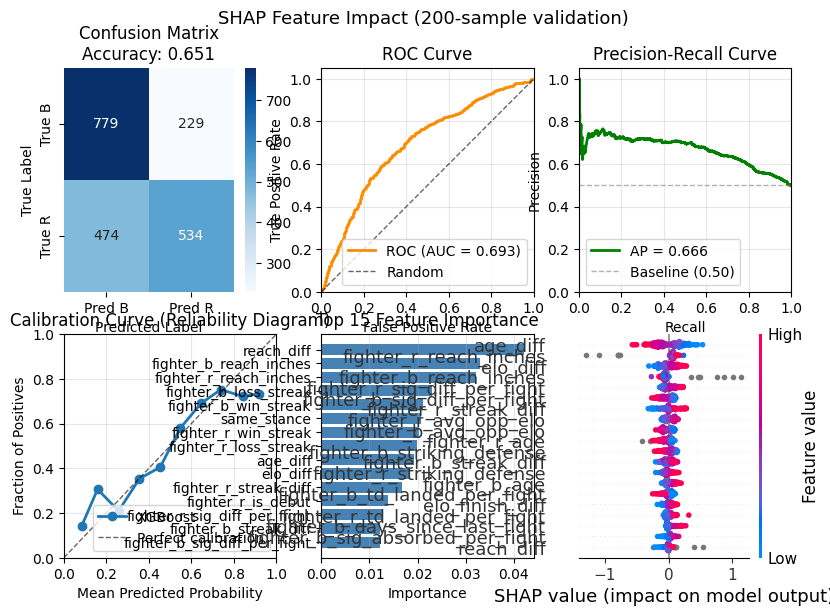


Diagnostic plots rendered above.


In [234]:
# ============================================================
# CELL 12b:
# FIX #7: feature importance index now matches the model's actual feature count. Model Evaluation — Visual Diagnostics
# Confusion matrix, ROC, PR curve, calibration, feature importance, SHAP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, precision_recall_curve,
    auc, average_precision_score, accuracy_score
)
from sklearn.calibration import calibration_curve

# ── Layout ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('XGBoost Model — Evaluation Diagnostics', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout(pad=5.0)

# ── 1. Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred B', 'Pred R'],
            yticklabels=['True B', 'True R'],
            ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {accuracy_score(y_val, y_pred):.3f}')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# ── 2. ROC Curve ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# ── 3. Precision-Recall Curve ──────────────────────────────
precision, recall, _ = precision_recall_curve(y_val, y_prob)
ap = average_precision_score(y_val, y_prob)
baseline_pr = y_val.mean()
axes[0, 2].plot(recall, precision, color='green', lw=2, label=f'AP = {ap:.3f}')
axes[0, 2].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                   alpha=0.6, label=f'Baseline ({baseline_pr:.2f})')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve')
axes[0, 2].legend(loc='lower left')
axes[0, 2].grid(alpha=0.3)

# ── 4. Calibration Curve ───────────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10, strategy='uniform')
axes[1, 0].plot(prob_pred, prob_true, marker='o', lw=2, label='XGBoost')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfect calibration')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.0])
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve (Reliability Diagram)')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# ── 5. Feature Importance (Top 15) ─────────────────────────
# v2-fix-1: safe length-matched feature importance
imp_df = pd.DataFrame({
    'feature':    feature_cols[:len(model.feature_importances_)],
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=True).tail(15)

axes[1, 1].barh(imp_df['feature'], imp_df['importance'], color='steelblue')
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 Feature Importance')
axes[1, 1].grid(alpha=0.3, axis='x')

# ── 6. SHAP Beeswarm (fallback to XGBoost importance) ─────
try:
    import shap
    X_val_sample = X_val.sample(min(200, len(X_val)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val_sample)
    shap.summary_plot(shap_values, X_val_sample, feature_names=feature_cols,
                      show=False, plot_size=(8, 6))
    shap_fig = plt.gcf()
    shap_fig.suptitle('SHAP Feature Impact (200-sample validation)', fontsize=13)
    print('SHAP beeswarm rendered.')
except Exception as e:
    from xgboost import plot_importance
    axes[1, 2].remove()
    ax_imp = fig.add_subplot(2, 3, 6)
    plot_importance(model.get_booster(), max_num_features=15, ax=ax_imp, importance_type='weight')
    ax_imp.set_title(f'XGBoost Importance (SHAP unavailable)')

plt.show()

print('\n' + '='*60)
print('Diagnostic plots rendered above.')
print('='*60)




In [235]:
# ============================================================
# CELL 12c: Comparison — Filter to fights >= 2005 only
# Pre-2005 data still feeds ELO/stats (Cells 5-6 run on all data).
# Only the train/eval split excludes pre-2005 fights.
# FIX: baseline_acc and baseline_acc_2005 are now computed locally
#      in this cell so they are always defined before the comparison table.
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb

# ── Full-dataset ELO baseline (unique fights) ────────────────────────────────
unique_val_full = val_df.drop_duplicates(subset='fight_id', keep='first')
elo_pred_full   = (unique_val_full['elo_diff'] > 0).astype(int)
baseline_acc    = accuracy_score(unique_val_full['target'], elo_pred_full)
print(f"Full-data ELO baseline (unique val fights): {baseline_acc:.4f}")

# ── 2005+ subset uses sym_df_2005 / train_df_2005 / val_df_2005 from Cell 10 ─
print(f"\n2005+ Train: {len(train_df_2005)} rows  ({train_df_2005['DATE'].min().date()} → {train_df_2005['DATE'].max().date()})")
print(f"2005+ Val:   {len(val_df_2005)} rows  ({val_df_2005['DATE'].min().date()} → {val_df_2005['DATE'].max().date()})")

X_train_2005 = train_df_2005[feature_cols]
y_train_2005 = train_df_2005['target']
X_val_2005   = val_df_2005[feature_cols]
y_val_2005   = val_df_2005['target']

# ── Train XGBoost on 2005+ data ──────────────────────────────────────────────
model_2005 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
)
model_2005.fit(
    X_train_2005, y_train_2005,
    eval_set=[(X_train_2005, y_train_2005), (X_val_2005, y_val_2005)],
    verbose=100,
)
print(f"\nBest iteration (2005+): {model_2005.best_iteration}")
print(f"Best validation logloss (2005+): {model_2005.best_score:.4f}")

# ── Evaluate 2005+ model ─────────────────────────────────────────────────────
y_pred_2005 = (model_2005.predict_proba(X_val_2005)[:, 1] >= 0.55).astype(int)
y_prob_2005 = model_2005.predict_proba(X_val_2005)[:, 1]

acc_2005 = accuracy_score(y_val_2005, y_pred_2005)
auc_2005 = roc_auc_score(y_val_2005, y_prob_2005)

print(f"\n2005+ Validation Accuracy: {acc_2005:.4f}")
print(f"2005+ Validation AUC-ROC:  {auc_2005:.4f}")
print(f"\n2005+ Confusion Matrix:")
print(confusion_matrix(y_val_2005, y_pred_2005))
print(f"\n2005+ Classification Report:")
print(classification_report(y_val_2005, y_pred_2005, target_names=['fighter_b wins', 'fighter_r wins']))

# ── 2005+ ELO baseline (unique fights) ───────────────────────────────────────
unique_val_2005   = val_df_2005.drop_duplicates(subset='fight_id', keep='first')
elo_pred_2005     = (unique_val_2005['elo_diff'] > 0).astype(int)
baseline_acc_2005 = accuracy_score(unique_val_2005['target'], elo_pred_2005)
print(f"\n2005+ ELO baseline (unique val fights): {baseline_acc_2005:.4f}")

# ── Side-by-side comparison table ────────────────────────────────────────────
print(f"\n{'='*60}")
print('Performance Comparison: All Data vs Post-2005 Only')
print(f"{'='*60}")
print(f'  {"Metric":<25} {"All Data":<12} {"Post-2005":<12} {"Delta":<12}')
print(f'  {"-"*25} {"-"*12} {"-"*12} {"-"*12}')
print(f'  {"Accuracy":<25} {accuracy:.4f}       {acc_2005:.4f}       {acc_2005 - accuracy:+.4f}')
print(f'  {"AUC-ROC":<25}  {roc_auc:.4f}       {auc_2005:.4f}       {auc_2005 - roc_auc:+.4f}')
print(f'  {"Baseline (ELO)":<25} {baseline_acc:.4f}       {baseline_acc_2005:.4f}       {baseline_acc_2005 - baseline_acc:+.4f}')
print(f'  {"Best logloss":<25}  {model.best_score:.4f}       {model_2005.best_score:.4f}       {model_2005.best_score - model.best_score:+.4f}')
print(f'  {"Train size":<25} {len(train_df):<12} {len(train_df_2005):<12}')
print(f'  {"Val size":<25}  {len(val_df):<12} {len(val_df_2005):<12}')

# ── Pre-2005 breakdown ────────────────────────────────────────────────────────
pre_2005_fights = sym_df[sym_df['DATE'] < '2005-01-01'].drop_duplicates('fight_id')
print(f"\nPre-2005 unique fights removed: {len(pre_2005_fights)}")
print(pre_2005_fights['DATE'].dt.year.value_counts().sort_index().to_string())


Full-data ELO baseline (unique val fights): 0.5446

2005+ Train: 14218 rows  (2005-02-05 → 2024-06-01)
2005+ Val:   2016 rows  (2024-06-08 → 2026-05-16)
[0]	validation_0-logloss:0.68956	validation_1-logloss:0.69177
[100]	validation_0-logloss:0.56282	validation_1-logloss:0.65078
[200]	validation_0-logloss:0.50290	validation_1-logloss:0.64704

Best iteration (2005+): 180
Best validation logloss (2005+): 0.6464

2005+ Validation Accuracy: 0.6389
2005+ Validation AUC-ROC:  0.6891

2005+ Confusion Matrix:
[[772 236]
 [492 516]]

2005+ Classification Report:
                precision    recall  f1-score   support

fighter_b wins       0.61      0.77      0.68      1008
fighter_r wins       0.69      0.51      0.59      1008

      accuracy                           0.64      2016
     macro avg       0.65      0.64      0.63      2016
  weighted avg       0.65      0.64      0.63      2016


2005+ ELO baseline (unique val fights): 0.5446

Performance Comparison: All Data vs Post-2005 Only
  

# Age as main predictor?

## Cell 14 — SHAP Dependence Plot: `age_diff`

### What this does
Computes SHAP values for the **post-2005 XGBoost model** (`model_2005`) on the
post-2005 validation set (`X_val_2005`) and plots a **SHAP dependence plot**
for the `age_diff` feature.

Each point is one fight:
- **x-axis**: the raw `age_diff` value (`fighter_r_age - fighter_b_age`)
  — positive means red-corner fighter is older, negative means younger.
- **y-axis**: the SHAP value for `age_diff` — this is the feature's impact on
  the model's log-odds prediction.
  - Positive → pushes prediction toward **red wins**.
  - Negative → pushes prediction toward **blue wins**.
- **Color**: the feature that most strongly **interacts** with `age_diff` at
  that point (auto-selected by SHAP). If the color gradient runs vertically,
  the age effect depends on that other feature.

### How to interpret
- **Slope**: If SHAP values trend upward as `age_diff` increases, the model
  thinks older-red fighters are more likely to win (and vice versa).
- **Spread at a given x value**: If there's wide vertical scatter at a fixed
  `age_diff`, it means the model's age effect is **context-dependent** —
  moderated by other features (the coloring reveals which one).
- **Color pattern**: A strong color gradient (e.g., red dots at top, blue at
  bottom) means the interacting feature largely determines *when* age matters.

### What it tells you
- Whether the model treats age as **monotonic** (always favors older or
  younger) or **nonlinear** (e.g., a moderate age gap helps, but a large one
  hurts).
- Which other feature(s) **mediate** the age effect — e.g., does age only
  matter when fighters have similar ELO? Or when reach is equal?


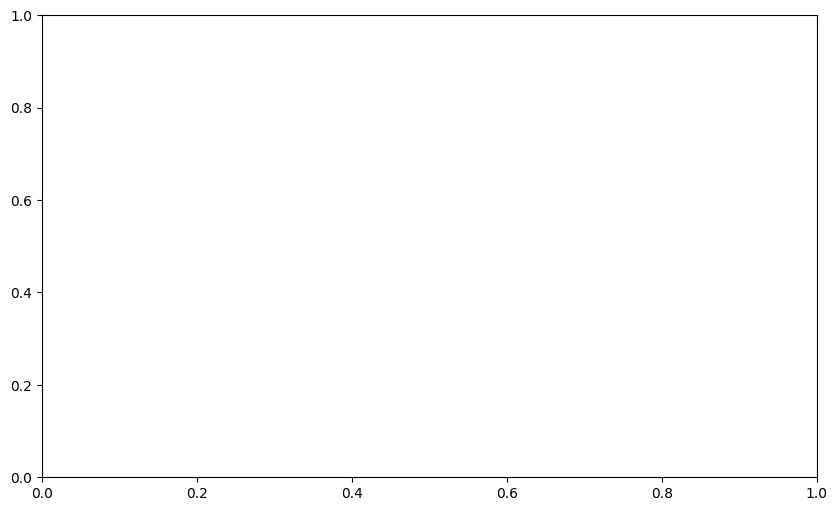

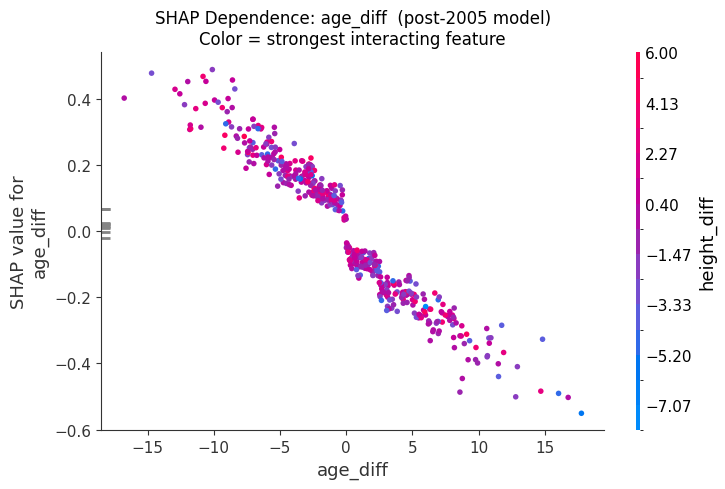


Top 5 features interacting with age_diff:
  fighter_r_num_fights       0.3397
  fighter_r_avg_opp_elo      0.2648
  fighter_r_champ_round_experience  0.2489
  fighter_r_striking_score   nan
  fighter_r_grappling_score  nan


In [236]:
# ============================================================
# CELL 14: SHAP Dependence Plot — age_diff (Post-2005 model)
# ============================================================
import shap
import matplotlib.pyplot as plt

# Reuse model_2005 and X_val_2005 from Cell 12c
explainer = shap.TreeExplainer(model_2005)

# Sample for speed (if needed)
X_shap = X_val_2005.sample(min(500, len(X_val_2005)), random_state=42)
shap_values = explainer.shap_values(X_shap)

# Dependence plot for age_diff, colored by strongest interaction
fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(
    'age_diff',
    shap_values,
    X_shap,
    feature_names=feature_cols,
    interaction_index='auto',
    show=False,
)
plt.title(
    'SHAP Dependence: age_diff  (post-2005 model)\n'
    'Color = strongest interacting feature'
)
plt.tight_layout()
plt.show()

# Print top interacting features
age_diff_idx = feature_cols.index('age_diff')
age_shap = shap_values[:, age_diff_idx]
correlations = []
for i, col in enumerate(feature_cols):
    if col == 'age_diff':
        continue
    corr = abs(pd.Series(age_shap).corr(pd.Series(X_shap[col].values)))
    correlations.append((col, corr))
correlations.sort(key=lambda x: x[1], reverse=True)

print('\nTop 5 features interacting with age_diff:')
for col, corr in correlations[:5]:
    print(f'  {col:25s}  {corr:.4f}')


## Cell 13 — Inference Demo


In [237]:
# ============================================================
# CELL 13: Inference Demo
# ============================================================

# Global defense averages (same computation as Cell 6)
g_striking_def = 1 - (global_stats['sum_sig_landed'] / global_stats['sum_sig_attempted'])
g_td_def = 1 - (global_stats['sum_td_landed'] / global_stats['sum_td_attempted'])

"""Predict winner for any hypothetical or upcoming fight."""

def predict_fight(fighter_a, fighter_b, fight_date,
                  histories, tott_df, xgb_model,
                  def_striking, def_td,
                  weight_class=None):
    """Return probability that fighter_a wins."""
    elo_a = histories.get(fighter_a, {}).get('elo', 1500)
    elo_b = histories.get(fighter_b, {}).get('elo', 1500)

    feats_a = compute_fighter_features(fighter_a, fight_date,
                                        histories, tott_df,
                                        opponent_elo=elo_b,
                                        weight_class=weight_class)
    feats_b = compute_fighter_features(fighter_b, fight_date,
                                        histories, tott_df,
                                        opponent_elo=elo_a,
                                        weight_class=weight_class)

    row = {}
    for k, v in feats_a.items():
        row[f'fighter_r_{k}'] = v
    for k, v in feats_b.items():
        row[f'fighter_b_{k}'] = v

    # Physical differences
    for attr, dname in [('reach_inches','reach_diff'),
                         ('height_inches','height_diff'),
                         ('weight_lbs','weight_diff')]:
        rv = row.get(f'fighter_r_{attr}')
        bv = row.get(f'fighter_b_{attr}')
        row[dname] = rv - bv if pd.notna(rv) and pd.notna(bv) else np.nan

    # Stance
    def _cs(s):
        if pd.isna(s): return np.nan
        s = str(s).strip().lower()
        return 'southpaw' if 'southpaw' in s else ('orthodox' if 'orthodox' in s else ('switch' if 'switch' in s else np.nan))

    sr, sb = _cs(row.get('fighter_r_stance')), _cs(row.get('fighter_b_stance'))
    row['same_stance'] = 1 if (pd.notna(sr) and pd.notna(sb) and sr == sb) else 0
    row['fighter_r_southpaw'] = (1 if sr == 'southpaw' else 0) - (1 if sb == 'southpaw' else 0)
    row['fighter_b_southpaw'] = 1 if sb == 'southpaw' else 0

    # Age from DOB
    dob_map = tott_df.set_index('FIGHTER')['DOB'].to_dict()
    for prefix, fname in [('fighter_r_', fighter_a), ('fighter_b_', fighter_b)]:
        dob = dob_map.get(fname)
        row[f'{prefix}age'] = (fight_date - dob).days / 365.25 if pd.notna(dob) else np.nan
    row['age_diff'] = row['fighter_r_age'] - row['fighter_b_age']
    for prefix in ['fighter_r_', 'fighter_b_']:
        age = row.get(f'{prefix}age')
        row[f'{prefix}age_sq'] = age ** 2 if pd.notna(age) else np.nan
        row[f'{prefix}age_cubed'] = age ** 3 if pd.notna(age) else np.nan

    # Opponent-adjusted scores
    def _adj(s_col, d_col, gavg):
        sv, dv = row.get(s_col), row.get(d_col)
        if pd.notna(sv) and pd.notna(dv) and gavg > 0:
            return sv * (dv / gavg)
        return sv

    row['adjusted_striking_r'] = _adj('fighter_r_striking_score', 'fighter_b_striking_defense', def_striking)
    row['adjusted_striking_b'] = _adj('fighter_b_striking_score', 'fighter_r_striking_defense', def_striking)
    row['adjusted_grappling_r'] = _adj('fighter_r_grappling_score', 'fighter_b_td_defense', def_td)
    row['adjusted_grappling_b'] = _adj('fighter_b_grappling_score', 'fighter_r_td_defense', def_td)

    row['elo_diff'] = row['fighter_r_elo'] - row['fighter_b_elo']
    row['elo_finish_diff'] = row['fighter_r_elo_finish'] - row['fighter_b_elo_finish']
    row['striking_score_diff'] = row['fighter_r_striking_score'] - row['fighter_b_striking_score']
    row['grappling_score_diff'] = row['fighter_r_grappling_score'] - row['fighter_b_grappling_score']
    row['num_fights_diff'] = row['fighter_r_num_fights'] - row['fighter_b_num_fights']
    row['champ_exp_diff'] = row['fighter_r_champ_round_experience'] - row['fighter_b_champ_round_experience']

    X_pred = pd.DataFrame([row])[feature_cols]
    prob = xgb_model.predict_proba(X_pred)[0, 1]
    return prob

# ------------------------------------------------------------------
# Demo: predict a hypothetical championship fight
# ------------------------------------------------------------------
demo_fighter_a = 'Islam Makhachev'
demo_fighter_b = 'Charles Oliveira'
demo_date = pd.Timestamp('2026-12-31')

prob = predict_fight(demo_fighter_a, demo_fighter_b, demo_date,
                     fighter_histories, tott_clean, model,
                     g_striking_def, g_td_def,
                     weight_class='Lightweight')

print(f'{"="*60}')
print(f'PREDICTION: {demo_fighter_a} vs {demo_fighter_b}')
print(f'{"="*60}')
print(f'{demo_fighter_a} win probability: {prob:.1%}')
print(f'{demo_fighter_b} win probability: {1-prob:.1%}')
print(f'{"="*60}')

# Fighter ELOs
elo_a = fighter_histories.get(demo_fighter_a, {}).get('elo', 'N/A')
elo_b = fighter_histories.get(demo_fighter_b, {}).get('elo', 'N/A')
print(f'{demo_fighter_a} ELO: {round(elo_a,2)}')
print(f'{demo_fighter_b} ELO: {round(elo_b, 2)}')

print('\nFeature vector columns:')
print(f'  {len(feature_cols)} features')


PREDICTION: Islam Makhachev vs Charles Oliveira
Islam Makhachev win probability: 81.7%
Charles Oliveira win probability: 18.3%
Islam Makhachev ELO: 1789.24
Charles Oliveira ELO: 1671.72

Feature vector columns:
  105 features


# MODEL COMPARISON

## Model Comparison: Random Forest & Logistic Regression

Adding Random Forest and Logistic Regression alongside the existing XGBoost for comparison.
Both require NaN imputation and missing-indicator features (XGBoost handles NaNs natively).
Logistic Regression additionally requires feature scaling.

### Cell 14a: Impute NaN, Add Missing Indicators, Scale for LR

- **Missing indicators**: For every feature with any NaN in X_train, add a binary `{col}_missing` column
- **Imputation**: Fill remaining NaNs with column median (fit on train, transform both)
- **Scaling**: StandardScaler (fit on train, transform both) — only used for Logistic Regression

In [238]:
# ============================================================
# CELL 14a: Impute NaN, Add Missing Indicators, Scale for LR
# v2-fix-1: Drop all-NaN columns BEFORE imputation to prevent shape mismatch.
#            Use imputer.feature_names_in_ as the authoritative column list.
# ============================================================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Make clean copies (X_train/X_val from Cell 10 stay untouched for XGBoost)
X_train_imp = X_train.copy()
X_val_imp   = X_val.copy()

# v2-fix-1: drop columns that are entirely NaN in training — imputer cannot
# infer a median for these and silently removes them, causing shape crashes.
all_nan_cols = [c for c in X_train_imp.columns if X_train_imp[c].isna().all()]
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns: {all_nan_cols}')
    X_train_imp.drop(columns=all_nan_cols, inplace=True)
    X_val_imp.drop(columns=all_nan_cols, errors='ignore', inplace=True)

# Columns with ANY NaN in training set (for missing indicators)
nan_cols = [c for c in X_train_imp.columns if X_train_imp[c].isna().any()]
for col in nan_cols:
    X_train_imp[f'{col}_missing'] = X_train_imp[col].isna().astype(int)
    X_val_imp[f'{col}_missing']   = X_val_imp[col].isna().astype(int)

# Align val to train columns (in case val has extra/missing indicator cols)
X_val_imp = X_val_imp.reindex(columns=X_train_imp.columns, fill_value=0)

# Median imputation — fit on train only
imputer = SimpleImputer(strategy='median')
X_train_imp_arr = imputer.fit_transform(X_train_imp)
X_val_imp_arr   = imputer.transform(X_val_imp)

# v2-fix-1: use the fitted imputer's column list — guaranteed to match output shape
feature_cols_imp = list(imputer.feature_names_in_)
X_train_imp = pd.DataFrame(X_train_imp_arr, columns=feature_cols_imp, index=X_train.index)
X_val_imp   = pd.DataFrame(X_val_imp_arr,   columns=feature_cols_imp, index=X_val.index)

assert X_train_imp.shape[1] == X_val_imp.shape[1], "Shape mismatch after imputation!"

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)

print(f'v2-fix-1 complete. X_train_imp: {X_train_imp.shape}, X_val_imp: {X_val_imp.shape}')
print(f'Training NaNs remaining: {X_train_imp.isna().sum().sum()}')


/var/folders/hh/chvnjps51cq8tc3xg4k6m1940000gn/T/ipykernel_59621/1566365050.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_imp[f'{col}_missing'] = X_train_imp[col].isna().astype(int)
/var/folders/hh/chvnjps51cq8tc3xg4k6m1940000gn/T/ipykernel_59621/1566365050.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val_imp[f'{col}_missing']   = X_val_imp[col].isna().astype(int)
/var/folders/hh/chvnjps51cq8tc3xg4k6m1940000gn/T/ipykernel_59621/1566365050.py:24: PerformanceWarning: DataFrame is highly fragmented.  This i

v2-fix-1 complete. X_train_imp: (15078, 207), X_val_imp: (2016, 207)
Training NaNs remaining: 0


### Cell 14b: Random Forest

Train a Random Forest on the imputed features (no scaling needed).
Same 80/20 temporal split, same evaluation metrics as XGBoost.

In [239]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_imp, y_train)

y_pred_rf = (rf.predict_proba(X_val_imp)[:, 1] >= 0.55).astype(int)
y_prob_rf = rf.predict_proba(X_val_imp)[:, 1]

acc_rf = accuracy_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_prob_rf)

print(f'Random Forest Validation Accuracy: {acc_rf:.4f}')
print(f'Random Forest Validation AUC-ROC:  {auc_rf:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_rf))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_rf, target_names=['fighter_b', 'fighter_r']))

Random Forest Validation Accuracy: 0.6210
Random Forest Validation AUC-ROC:  0.6918

Confusion Matrix:
[[813 195]
 [569 439]]

Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.59      0.81      0.68      1008
   fighter_r       0.69      0.44      0.53      1008

    accuracy                           0.62      2016
   macro avg       0.64      0.62      0.61      2016
weighted avg       0.64      0.62      0.61      2016



### Cell 14c: Logistic Regression

Train a Logistic Regression on the imputed + scaled features.
Simple baseline — coefficients directly show feature importance direction.

In [240]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_scaled, y_train)

y_pred_lr = (lr.predict_proba(X_val_scaled)[:, 1] >= 0.55).astype(int)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]

acc_lr = accuracy_score(y_val, y_pred_lr)
auc_lr = roc_auc_score(y_val, y_prob_lr)

print(f'Logistic Regression Validation Accuracy: {acc_lr:.4f}')
print(f'Logistic Regression Validation AUC-ROC:  {auc_lr:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_lr))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_lr, target_names=['fighter_b', 'fighter_r']))

Logistic Regression Validation Accuracy: 0.6324
Logistic Regression Validation AUC-ROC:  0.6717

Confusion Matrix:
[[756 252]
 [489 519]]

Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.61      0.75      0.67      1008
   fighter_r       0.67      0.51      0.58      1008

    accuracy                           0.63      2016
   macro avg       0.64      0.63      0.63      2016
weighted avg       0.64      0.63      0.63      2016



### Cell 14d: Side-by-Side Comparison (Full Dataset)

Compare all three models on the same validation set.

In [241]:
from sklearn.metrics import precision_recall_fscore_support

print(f'{"="*70}')
print(f'{"Model Comparison 2014 Full Dataset Validation":^70}')
print(f'{"="*70}')
header = f'{"Model":<20} {"Accuracy":<12} {"AUC-ROC":<12} {"Prec (R)":<12} {"Recall (R)":<12} {"F1 (R)":<12}'
sep    = f'{"-"*20} {"-"*12} {"-"*12} {"-"*12} {"-"*12} {"-"*12}'
print(header)
print(sep)

p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_val, y_pred, labels=[1])
print(f'{"XGBoost":<20} {accuracy:<12.4f} {roc_auc:<12.4f} {p_xgb[0]:<12.4f} {r_xgb[0]:<12.4f} {f1_xgb[0]:<12.4f}')

p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_val, y_pred_rf, labels=[1])
print(f'{"Random Forest":<20} {acc_rf:<12.4f} {auc_rf:<12.4f} {p_rf[0]:<12.4f} {r_rf[0]:<12.4f} {f1_rf[0]:<12.4f}')

p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_val, y_pred_lr, labels=[1])
print(f'{"Logistic Reg":<20} {acc_lr:<12.4f} {auc_lr:<12.4f} {p_lr[0]:<12.4f} {r_lr[0]:<12.4f} {f1_lr[0]:<12.4f}')

print(f'\nBaseline (higher ELO wins): {baseline_acc:.4f}')
# ── FIX #8: ELO baseline comparison (unique fights) ──────────────────────────
print(f'\n{"="*70}')
print('BASELINE COMPARISON (unique val fights)')
print(f'{"="*70}')
unique_val = val_df.drop_duplicates(subset='fight_id', keep='first')
y_val_uniq  = unique_val['target']
elo_pred    = (unique_val['elo_diff'] > 0).astype(int)
elo_acc     = accuracy_score(y_val_uniq, elo_pred)
print(f'  ELO baseline (higher ELO wins): {elo_acc:.4f}')
for name, clf in [('XGBoost', model), ('Random Forest', rf), ('Logistic Regression', lr)]:
    try:
        acc = accuracy_score(y_val_uniq, clf.predict(unique_val[feature_cols]))
        print(f'  {name:<25s}: {acc:.4f}  (lift over ELO: {acc - elo_acc:+.4f})')
    except Exception as e:
        print(f'  {name:<25s}: could not evaluate ({e})')


            Model Comparison 2014 Full Dataset Validation             
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------------ ------------ ------------
XGBoost              0.6513       0.6934       0.6999       0.5298       0.6030      
Random Forest        0.6210       0.6918       0.6924       0.4355       0.5347      
Logistic Reg         0.6324       0.6717       0.6732       0.5149       0.5835      

Baseline (higher ELO wins): 0.5446

BASELINE COMPARISON (unique val fights)
  ELO baseline (higher ELO wins): 0.5446
  XGBoost                  : 0.6548  (lift over ELO: +0.1101)
  Random Forest            : could not evaluate (The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- adjusted_grappling_b_missing
- adjusted_grappling_r_missing
- adjusted_striking_b_missing
- adjusted_striking_r_missing
- age_diff_missing
- ...
)
  Logi

/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Repeat on Post-2005 Subset

Same pipeline (imputation \u2192 RF \u2192 LR \u2192 comparison) but training/evaluating only on fights from 2005 onward,
to see if model performance improves with cleaner modern-era data.

### Cell 15a: Post-2005 — Imputation, RF, LR, and Comparison

In [242]:
# ============================================================
# CELL 15a: Post-2005 — Imputation, RF, LR, and Comparison
# v2-fix-1: same all-NaN column drop + feature_names_in_ pattern as cell14a.
# ============================================================
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_recall_fscore_support

X_train_2005_imp = train_df_2005[feature_cols].copy()
X_val_2005_imp   = val_df_2005[feature_cols].copy()
y_train_2005     = train_df_2005['target']
y_val_2005       = val_df_2005['target']

# v2-fix-1: drop all-NaN columns before imputation
all_nan_2005 = [c for c in X_train_2005_imp.columns if X_train_2005_imp[c].isna().all()]
if all_nan_2005:
    print(f'Dropping {len(all_nan_2005)} all-NaN cols (2005+): {all_nan_2005}')
    X_train_2005_imp.drop(columns=all_nan_2005, inplace=True)
    X_val_2005_imp.drop(columns=all_nan_2005, errors='ignore', inplace=True)

nan_cols_2005 = [c for c in X_train_2005_imp.columns if X_train_2005_imp[c].isna().any()]
for col in nan_cols_2005:
    X_train_2005_imp[f'{col}_missing'] = X_train_2005_imp[col].isna().astype(int)
    X_val_2005_imp[f'{col}_missing']   = X_val_2005_imp[col].isna().astype(int)

X_val_2005_imp = X_val_2005_imp.reindex(columns=X_train_2005_imp.columns, fill_value=0)

imputer_2005 = SimpleImputer(strategy='median')
X_train_2005_arr = imputer_2005.fit_transform(X_train_2005_imp)
X_val_2005_arr   = imputer_2005.transform(X_val_2005_imp)

feature_cols_imp_2005 = list(imputer_2005.feature_names_in_)
X_train_imp_2005 = pd.DataFrame(X_train_2005_arr, columns=feature_cols_imp_2005, index=train_df_2005.index)
X_val_imp_2005   = pd.DataFrame(X_val_2005_arr,   columns=feature_cols_imp_2005, index=val_df_2005.index)

assert X_train_imp_2005.shape[1] == X_val_imp_2005.shape[1], "Shape mismatch (2005+)!"

scaler_2005 = StandardScaler()
X_train_scaled_2005 = scaler_2005.fit_transform(X_train_imp_2005)
X_val_scaled_2005   = scaler_2005.transform(X_val_imp_2005)

# ---- XGBoost on 2005+ (re-evaluate from Cell 12c) ----
X_val_2005_xgb  = val_df_2005[feature_cols]
y_pred_2005     = (model_2005.predict_proba(X_val_2005_xgb)[:, 1] >= 0.55).astype(int)
y_prob_2005     = model_2005.predict_proba(X_val_2005_xgb)[:, 1]
acc_xgb_2005    = accuracy_score(y_val_2005, y_pred_2005)
auc_xgb_2005    = roc_auc_score(y_val_2005, y_prob_2005)

# ---- RF on 2005+ ----
rf_2005 = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_leaf=5,
                                  random_state=42, n_jobs=-1)
rf_2005.fit(X_train_imp_2005, y_train_2005)
y_pred_rf_2005  = (rf_2005.predict_proba(X_val_imp_2005)[:, 1] >= 0.55).astype(int)
y_prob_rf_2005  = rf_2005.predict_proba(X_val_imp_2005)[:, 1]
acc_rf_2005     = accuracy_score(y_val_2005, y_pred_rf_2005)
auc_rf_2005     = roc_auc_score(y_val_2005, y_prob_rf_2005)
print(f'2005+ Random Forest — Acc: {acc_rf_2005:.4f}, AUC: {auc_rf_2005:.4f}')
print(classification_report(y_val_2005, y_pred_rf_2005, target_names=['fighter_b', 'fighter_r']))

# ---- LR on 2005+ ----
lr_2005 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
lr_2005.fit(X_train_scaled_2005, y_train_2005)
y_pred_lr_2005  = (lr_2005.predict_proba(X_val_scaled_2005)[:, 1] >= 0.55).astype(int)
y_prob_lr_2005  = lr_2005.predict_proba(X_val_scaled_2005)[:, 1]
acc_lr_2005     = accuracy_score(y_val_2005, y_pred_lr_2005)
auc_lr_2005     = roc_auc_score(y_val_2005, y_prob_lr_2005)
print(f'2005+ Logistic Reg — Acc: {acc_lr_2005:.4f}, AUC: {auc_lr_2005:.4f}')
print(classification_report(y_val_2005, y_pred_lr_2005, target_names=['fighter_b', 'fighter_r']))

# ---- Comparison table ----
print(f'\n{"="*70}')
print(f'{"Model Comparison — Post-2005 Validation":^70}')
print(f'{"="*70}')
print(header)
print(sep)

p_xgb2, r_xgb2, f1_xgb2, _ = precision_recall_fscore_support(y_val_2005, y_pred_2005, labels=[1])
print(f'{"XGBoost":<20} {acc_xgb_2005:<12.4f} {auc_xgb_2005:<12.4f} {p_xgb2[0]:<12.4f} {r_xgb2[0]:<12.4f} {f1_xgb2[0]:<12.4f}')

p_rf2, r_rf2, f1_rf2, _ = precision_recall_fscore_support(y_val_2005, y_pred_rf_2005, labels=[1])
print(f'{"Random Forest":<20} {acc_rf_2005:<12.4f} {auc_rf_2005:<12.4f} {p_rf2[0]:<12.4f} {r_rf2[0]:<12.4f} {f1_rf2[0]:<12.4f}')

p_lr2, r_lr2, f1_lr2, _ = precision_recall_fscore_support(y_val_2005, y_pred_lr_2005, labels=[1])
print(f'{"Logistic Reg":<20} {acc_lr_2005:<12.4f} {auc_lr_2005:<12.4f} {p_lr2[0]:<12.4f} {r_lr2[0]:<12.4f} {f1_lr2[0]:<12.4f}')

# ELO baseline — unique val fights only
unique_val_2005   = val_df_2005.drop_duplicates(subset='fight_id', keep='first')
elo_pred_2005     = (unique_val_2005['elo_diff'] > 0).astype(int)
baseline_acc_2005 = accuracy_score(unique_val_2005['target'], elo_pred_2005)
print(f'\nBaseline (higher ELO wins, unique fights): {baseline_acc_2005:.4f}')


Dropping 10 all-NaN cols (2005+): ['fighter_r_striking_score', 'fighter_r_grappling_score', 'fighter_b_striking_score', 'fighter_b_grappling_score', 'adjusted_striking_r', 'adjusted_striking_b', 'adjusted_grappling_r', 'adjusted_grappling_b', 'striking_score_diff', 'grappling_score_diff']
2005+ Random Forest — Acc: 0.6265, AUC: 0.6928
              precision    recall  f1-score   support

   fighter_b       0.59      0.81      0.68      1008
   fighter_r       0.70      0.44      0.54      1008

    accuracy                           0.63      2016
   macro avg       0.65      0.63      0.61      2016
weighted avg       0.65      0.63      0.61      2016

2005+ Logistic Reg — Acc: 0.6285, AUC: 0.6778
              precision    recall  f1-score   support

   fighter_b       0.60      0.74      0.67      1008
   fighter_r       0.67      0.51      0.58      1008

    accuracy                           0.63      2016
   macro avg       0.64      0.63      0.62      2016
weighted avg      

### Cell 15b: Overall Comparison — Full + Post-2005

Final comparison grid showing all three models across both data slices.

In [243]:
print(f'{"="*80}')
print(f'{"OVERALL MODEL COMPARISON":^80}')
print(f'{"="*80}')
print()
print(f'{"Full Dataset (1994-2026)":^80}')
print(f'{"-"*80}')
print(header)
print(sep)
print(f'{"XGBoost":<20} {accuracy:<12.4f} {roc_auc:<12.4f} {p_xgb[0]:<12.4f} {r_xgb[0]:<12.4f} {f1_xgb[0]:<12.4f}')
print(f'{"Random Forest":<20} {acc_rf:<12.4f} {auc_rf:<12.4f} {p_rf[0]:<12.4f} {r_rf[0]:<12.4f} {f1_rf[0]:<12.4f}')
print(f'{"Logistic Reg":<20} {acc_lr:<12.4f} {auc_lr:<12.4f} {p_lr[0]:<12.4f} {r_lr[0]:<12.4f} {f1_lr[0]:<12.4f}')
print(f'\nBaseline (ELO): {baseline_acc:.4f}')
print()
print(f'{"Post-2005 Only":^80}')
print(f'{"-"*80}')
print(header)
print(sep)
print(f'{"XGBoost":<20} {acc_xgb_2005:<12.4f} {auc_xgb_2005:<12.4f} {p_xgb2[0]:<12.4f} {r_xgb2[0]:<12.4f} {f1_xgb2[0]:<12.4f}')
print(f'{"Random Forest":<20} {acc_rf_2005:<12.4f} {auc_rf_2005:<12.4f} {p_rf2[0]:<12.4f} {r_rf2[0]:<12.4f} {f1_rf2[0]:<12.4f}')
print(f'{"Logistic Reg":<20} {acc_lr_2005:<12.4f} {auc_lr_2005:<12.4f} {p_lr2[0]:<12.4f} {r_lr2[0]:<12.4f} {f1_lr2[0]:<12.4f}')
print(f'\nBaseline (ELO): {baseline_acc_2005:.4f}')

                            OVERALL MODEL COMPARISON                            

                            Full Dataset (1994-2026)                            
--------------------------------------------------------------------------------
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------------ ------------ ------------
XGBoost              0.6513       0.6934       0.6999       0.5298       0.6030      
Random Forest        0.6210       0.6918       0.6924       0.4355       0.5347      
Logistic Reg         0.6324       0.6717       0.6732       0.5149       0.5835      

Baseline (ELO): 0.5446

                                 Post-2005 Only                                 
--------------------------------------------------------------------------------
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------

In [250]:
import seaborn as sns   
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
# ── 4. Calibration Curve (Reliability Diagram) ─────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10)
axes[1, 0].plot(prob_pred, prob_true, marker='o', label='XGBoost', color='steelblue')
axes[1, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
axes[1, 0].set_title('Calibration Curve (Reliability Diagram)')
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')    

axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ── 5. Feature Importance (XGBoost) ───────────────────────────────────────
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False).head(15)   
sns.barplot(x='importance', y='feature', data=imp_df, ax=axes[1, 1], palette='viridis') 
axes[1, 1].set_title('XGBoost Feature Importance (Top 15)')
axes[1, 1].set_xlabel('Importance Score')
axes[1, 1].set_ylabel('Feature')
axes[1, 1].grid(alpha=0.3)  

      

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

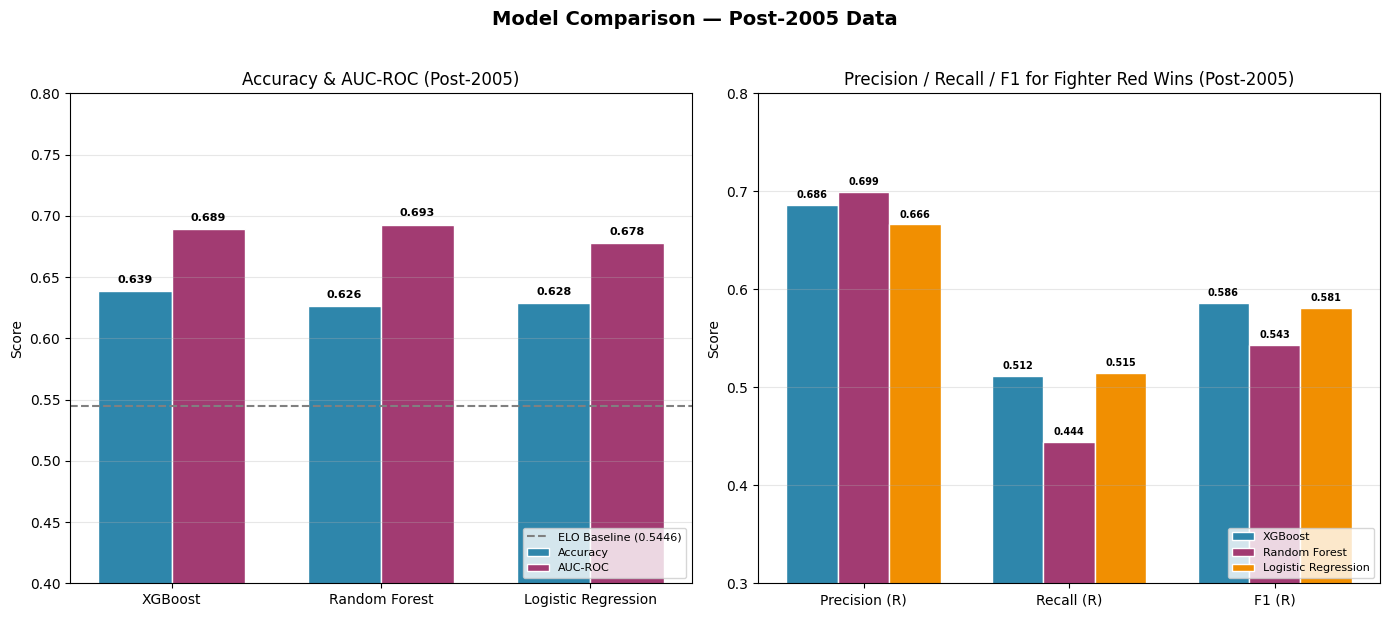

ELO baseline accuracy: 0.5446


In [245]:
# ============================================================
# CELL 15c: Post-2005 Model Comparison — Visual
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Data from Cell 15a (Post-2005 only)
models = ['XGBoost', 'Random Forest', 'Logistic Regression']
metrics = ['Accuracy', 'AUC-ROC', 'Precision (R)', 'Recall (R)', 'F1 (R)']

values = np.array([
    [acc_xgb_2005, auc_xgb_2005, p_xgb2[0], r_xgb2[0], f1_xgb2[0]],
    [acc_rf_2005,  auc_rf_2005,  p_rf2[0],  r_rf2[0],  f1_rf2[0]],
    [acc_lr_2005,  auc_lr_2005,  p_lr2[0],  r_lr2[0],  f1_lr2[0]],
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01']
x = np.arange(len(models))
width = 0.35

# ── Left panel: Accuracy + AUC-ROC ────────────────────────
ax = axes[0]
bars1 = ax.bar(x - width/2, values[:, 0], width, label='Accuracy', color=colors[0], edgecolor='white')
bars2 = ax.bar(x + width/2, values[:, 1], width, label='AUC-ROC', color=colors[1], edgecolor='white')

# ELO baseline line
ax.axhline(y=baseline_acc_2005, color='gray', linestyle='--', linewidth=1.5,
           label=f'ELO Baseline ({baseline_acc_2005:.4f})')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Accuracy & AUC-ROC (Post-2005)')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.4, 0.8)
ax.grid(axis='y', alpha=0.3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Right panel: Precision, Recall, F1 ────────────────────
ax = axes[1]
x2 = np.arange(len(metrics) - 2)  # 3 metrics
width2 = 0.25

for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - 1) * width2
    bars = ax.bar(x2 + offset, values[i, 2:], width2, label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x2)
ax.set_xticklabels(metrics[2:])
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 for Fighter Red Wins (Post-2005)')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.3, 0.8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Comparison — Post-2005 Data', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

print(f'ELO baseline accuracy: {baseline_acc_2005:.4f}')


# FINE TUNING THRESHOLD to keep red bias under control

## Cell 16: Threshold Tuning

Scans thresholds 0.30–0.70 for each model on both data subsets to find the optimal cutoff.
Compares tuned accuracy vs the current 0.55 default.

In [246]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def find_best_threshold(y_true, y_prob, model_label, thresholds=range(30, 71)):
    best_t, best_acc = 0.5, 0
    results = []
    for t in [x/100 for x in thresholds]:
        y_t = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_t)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_t, labels=[1])
        results.append({'threshold': t, 'accuracy': acc, 'prec_r': p[0], 'recall_r': r[0], 'f1_r': f1[0]})
        if acc > best_acc:
            best_t, best_acc = t, acc

    best_row = [r for r in results if r['threshold'] == best_t][0]
    def50    = [r for r in results if r['threshold'] == 0.50][0]
    def55    = [r for r in results if r['threshold'] == 0.55][0]

    print(f'\n{model_label}')
    print(f'  Optimal: threshold={best_t:.2f}  acc={best_acc:.4f}  prec(R)={best_row["prec_r"]:.4f}  recall(R)={best_row["recall_r"]:.4f}  f1(R)={best_row["f1_r"]:.4f}')
    print(f'  At 0.50:  acc={def50["accuracy"]:.4f}  prec(R)={def50["prec_r"]:.4f}  recall(R)={def50["recall_r"]:.4f}  f1(R)={def50["f1_r"]:.4f}')
    print(f'  At 0.55:  acc={def55["accuracy"]:.4f}  prec(R)={def55["prec_r"]:.4f}  recall(R)={def55["recall_r"]:.4f}  f1(R)={def55["f1_r"]:.4f}')
    return best_t, best_acc, results

print('='*80)
print('THRESHOLD TUNING RESULTS')
print('='*80)

# ---- Full dataset ----
print(f'\n>>> Full Dataset')
t_xgb,  a_xgb,  _ = find_best_threshold(y_val, y_prob, 'XGBoost')
t_rf,   a_rf,   _ = find_best_threshold(y_val, y_prob_rf, 'Random Forest')
t_lr,   a_lr,   _ = find_best_threshold(y_val, y_prob_lr, 'Logistic Reg')

# ---- Post-2005 ----
print(f'\n>>> Post-2005')
t_xgb5, a_xgb5, _ = find_best_threshold(y_val_2005, y_prob_2005, 'XGBoost')
t_rf5,  a_rf5,  _ = find_best_threshold(y_val_2005, y_prob_rf_2005, 'Random Forest')
t_lr5,  a_lr5,  _ = find_best_threshold(y_val_2005, y_prob_lr_2005, 'Logistic Reg')

# ---- Summary table ----
print(f'\n{"="*80}')
print('SUMMARY — Optimal Threshold vs Default 0.55')
print('='*80)
h = f'{"Model":<25} {"Data":<12} {"Opt T":<8} {"Opt Acc":<12} {"55 Acc":<12} {"Gain":<10}'
print(h)
print(f'{"-"*25} {"-"*12} {"-"*8} {"-"*12} {"-"*12} {"-"*10}')

rows = [
    ('XGBoost', 'Full', t_xgb, a_xgb, accuracy_score(y_val, (y_prob >= 0.55).astype(int))),
    ('Random Forest', 'Full', t_rf, a_rf, accuracy_score(y_val, (y_prob_rf >= 0.55).astype(int))),
    ('Logistic Reg', 'Full', t_lr, a_lr, accuracy_score(y_val, (y_prob_lr >= 0.55).astype(int))),
    ('XGBoost', '2005+', t_xgb5, a_xgb5, accuracy_score(y_val_2005, (y_prob_2005 >= 0.55).astype(int))),
    ('Random Forest', '2005+', t_rf5, a_rf5, accuracy_score(y_val_2005, (y_prob_rf_2005 >= 0.55).astype(int))),
    ('Logistic Reg', '2005+', t_lr5, a_lr5, accuracy_score(y_val_2005, (y_prob_lr_2005 >= 0.55).astype(int))),
]
for model, data, opt_t, opt_acc, acc55 in rows:
    gain = opt_acc - acc55
    print(f'{model:<25} {data:<12} {opt_t:<8.2f} {opt_acc:<12.4f} {acc55:<12.4f} {gain:<+10.4f}')

THRESHOLD TUNING RESULTS

>>> Full Dataset

XGBoost
  Optimal: threshold=0.52  acc=0.6538  prec(R)=0.6753  recall(R)=0.5923  f1(R)=0.6311
  At 0.50:  acc=0.6503  prec(R)=0.6520  recall(R)=0.6448  f1(R)=0.6484
  At 0.55:  acc=0.6513  prec(R)=0.6999  recall(R)=0.5298  f1(R)=0.6030

Random Forest
  Optimal: threshold=0.50  acc=0.6538  prec(R)=0.6544  recall(R)=0.6518  f1(R)=0.6531
  At 0.50:  acc=0.6538  prec(R)=0.6544  recall(R)=0.6518  f1(R)=0.6531
  At 0.55:  acc=0.6210  prec(R)=0.6924  recall(R)=0.4355  f1(R)=0.5347

Logistic Reg
  Optimal: threshold=0.50  acc=0.6438  prec(R)=0.6438  recall(R)=0.6438  f1(R)=0.6438
  At 0.50:  acc=0.6438  prec(R)=0.6438  recall(R)=0.6438  f1(R)=0.6438
  At 0.55:  acc=0.6324  prec(R)=0.6732  recall(R)=0.5149  f1(R)=0.5835

>>> Post-2005

XGBoost
  Optimal: threshold=0.52  acc=0.6533  prec(R)=0.6678  recall(R)=0.6101  f1(R)=0.6376
  At 0.50:  acc=0.6478  prec(R)=0.6472  recall(R)=0.6498  f1(R)=0.6485
  At 0.55:  acc=0.6389  prec(R)=0.6862  recall(R)=0.51

Post-2005 — Tuned Threshold Results
Model                Thresh   Acc      AUC      Prec(R)    Rec(R)     F1(R)     
----------------------------------------------------------------------
XGBoost              0.52     0.6533   0.6891   0.6678     0.6101     0.6376    
Random Forest        0.50     0.6523   0.6928   0.6530     0.6498     0.6514    
Logistic Regression  0.49     0.6503   0.6778   0.6436     0.6736     0.6583    
ELO baseline: 0.5446


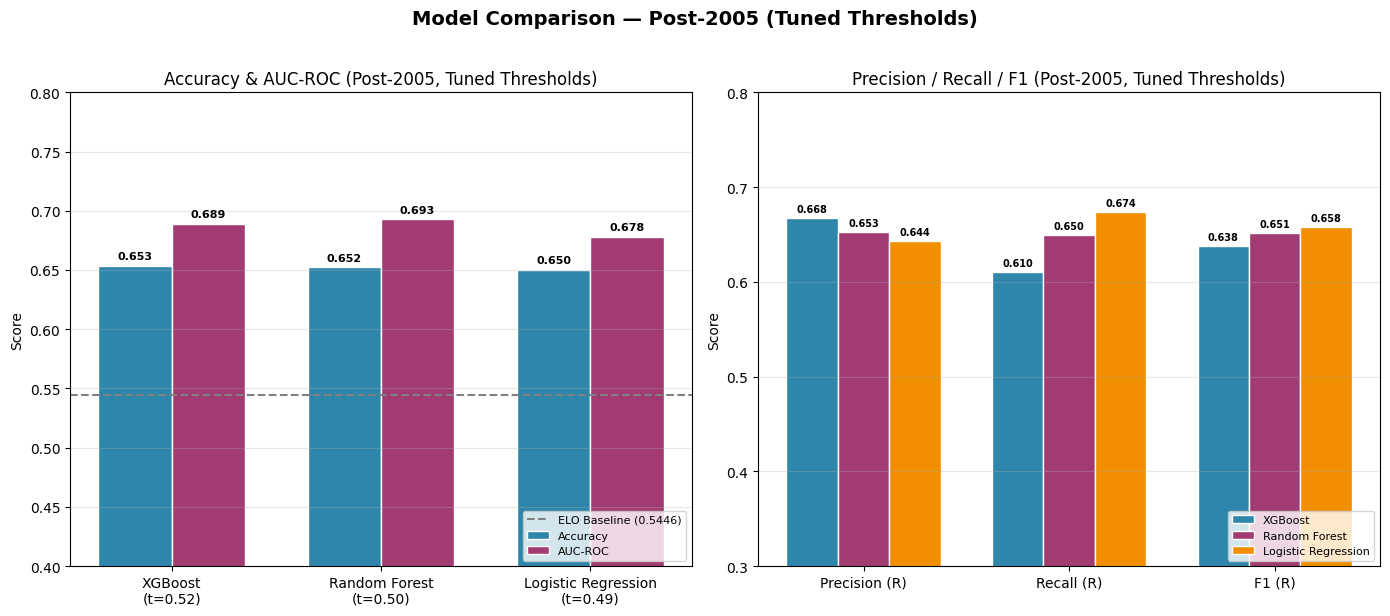

In [247]:
# ============================================================
# CELL 16b: Post-2005 Model Comparison — Tuned Thresholds
# Re-predicts using fitted models to guarantee shape alignment.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support

# ---- Ground truth from val_df_2005 ----
y_val_2005 = val_df_2005['target'].values

# ---- Re-predict with each model using the optimal thresholds from Cell 16 ----
y_prob_2005    = model_2005.predict_proba(val_df_2005[feature_cols])[:, 1]
y_prob_rf_2005 = rf_2005.predict_proba(X_val_imp_2005)[:, 1]
y_prob_lr_2005 = lr_2005.predict_proba(X_val_scaled_2005)[:, 1]

y_pred_xgb_tuned = (y_prob_2005    >= t_xgb5).astype(int)
y_pred_rf_tuned  = (y_prob_rf_2005 >= t_rf5).astype(int)
y_pred_lr_tuned  = (y_prob_lr_2005 >= t_lr5).astype(int)

models = ['XGBoost', 'Random Forest', 'Logistic Regression']
thresholds = [t_xgb5, t_rf5, t_lr5]
preds  = [y_pred_xgb_tuned, y_pred_rf_tuned, y_pred_lr_tuned]
probs  = [y_prob_2005, y_prob_rf_2005, y_prob_lr_2005]

# ---- Recompute metrics ----
accs, aucs, precs, recs, f1s = [], [], [], [], []
for yp, yt in zip(preds, probs):
    accs.append(accuracy_score(y_val_2005, yp))
    aucs.append(roc_auc_score(y_val_2005, yt))
    p, r, f1, _ = precision_recall_fscore_support(y_val_2005, yp, labels=[1])
    precs.append(p[0])
    recs.append(r[0])
    f1s.append(f1[0])

# ---- ELO baseline on unique fights ----
unique_val = val_df_2005.drop_duplicates(subset='fight_id', keep='first')
baseline_acc_2005 = accuracy_score(unique_val['target'], (unique_val['elo_diff'] > 0).astype(int))

print('Post-2005 — Tuned Threshold Results')
print(f'{"Model":<20} {"Thresh":<8} {"Acc":<8} {"AUC":<8} {"Prec(R)":<10} {"Rec(R)":<10} {"F1(R)":<10}')
print('-'*70)
for i, m in enumerate(models):
    print(f'{m:<20} {thresholds[i]:<8.2f} {accs[i]:<8.4f} {aucs[i]:<8.4f} {precs[i]:<10.4f} {recs[i]:<10.4f} {f1s[i]:<10.4f}')
print(f'ELO baseline: {baseline_acc_2005:.4f}')

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01']
x = np.arange(len(models))
width = 0.35

# Left: Accuracy + AUC
ax = axes[0]
vals = np.column_stack([accs, aucs])
bars1 = ax.bar(x - width/2, vals[:, 0], width, label='Accuracy', color=colors[0], edgecolor='white')
bars2 = ax.bar(x + width/2, vals[:, 1], width, label='AUC-ROC', color=colors[1], edgecolor='white')
ax.axhline(y=baseline_acc_2005, color='gray', linestyle='--', linewidth=1.5,
           label=f'ELO Baseline ({baseline_acc_2005:.4f})')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}\n(t={t:.2f})' for m, t in zip(models, thresholds)])
ax.set_ylabel('Score')
ax.set_title('Accuracy & AUC-ROC (Post-2005, Tuned Thresholds)')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.4, 0.8)
ax.grid(axis='y', alpha=0.3)

# Right: Precision, Recall, F1
ax = axes[1]
x2 = np.arange(3)
width2 = 0.25
for i, (model, color) in enumerate(zip(models, colors)):
    offset = (i - 1) * width2
    bars = ax.bar(x2 + offset, [precs[i], recs[i], f1s[i]], width2,
                  label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(['Precision (R)', 'Recall (R)', 'F1 (R)'])
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 (Post-2005, Tuned Thresholds)')
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.3, 0.8)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Comparison — Post-2005 (Tuned Thresholds)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


# The Other Model 
Logistic regression – is the Meta the real predictor for fights?

## Cell 17: Rolling Window Meta Analysis

Trains Logistic Regression on sliding 3-year windows (every 6 months) from 2005 onward.
Tracks how each advantage feature's coefficient changes over time.
Shows which types of advantages rose/declined in importance over UFC history.

Building rolling window meta models...
Using 10 advantage features: ['elo_diff', 'striking_score_diff', 'grappling_score_diff', 'num_fights_diff', 'champ_exp_diff', 'reach_diff', 'height_diff', 'age_diff', 'fighter_r_southpaw', 'weight_diff']
Trained 37 window models
Date range: 2006-07-02 to 2024-07-15
Window sizes: 812 - 3074 fights
Window accuracy range: 0.570 to 0.671

Average |coefficient| by feature (higher = more important):
age_diff              0.318782
elo_diff              0.314613
weight_diff           0.148013
num_fights_diff       0.119614
height_diff           0.101211
fighter_r_southpaw    0.087267
reach_diff            0.073413
champ_exp_diff        0.066967


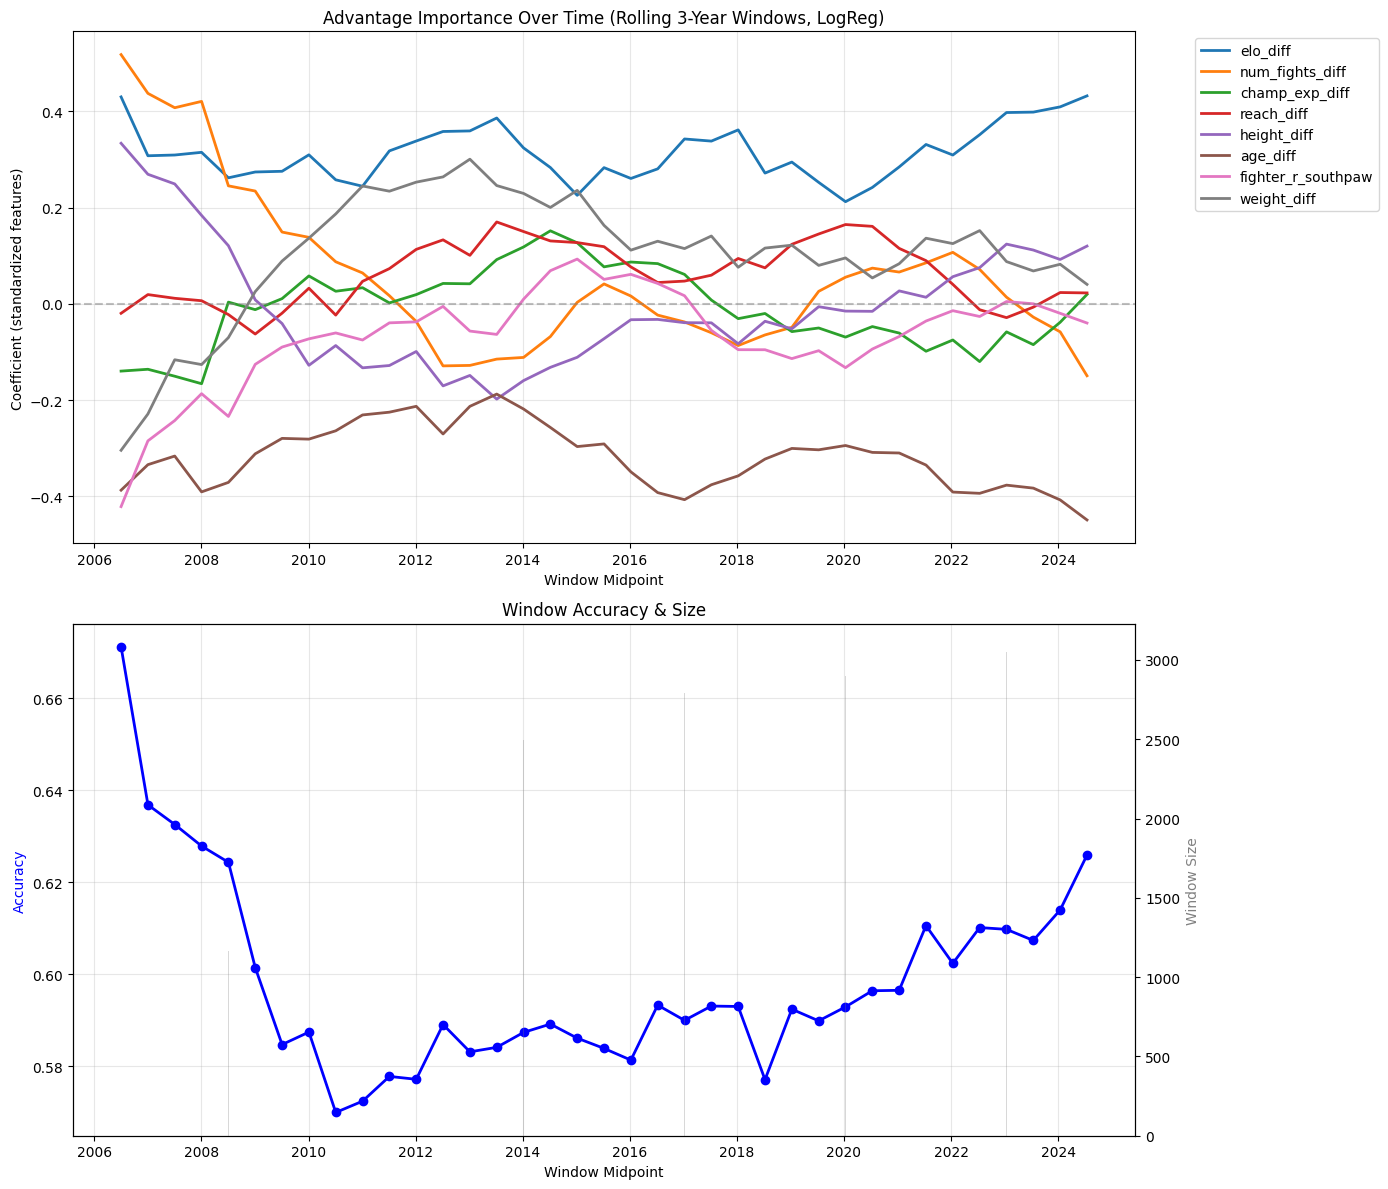

In [248]:
# ============================================================
# CELL 17: Rolling Window Meta Analysis
# v2-fix-2: store per-window feature list (window_features) alongside each
#            model so coeff_df and cell18 inference always use the exact
#            columns the model was trained on — never the global 'available' list.
# ============================================================

print('Building rolling window meta models...')

advantage_features_cols = [
    'elo_diff', 'striking_score_diff', 'grappling_score_diff',
    'num_fights_diff', 'champ_exp_diff', 'reach_diff',
    'height_diff', 'age_diff', 'fighter_r_southpaw', 'weight_diff'
]

available = [f for f in advantage_features_cols if f in sym_df_2005.columns]
print(f'Using {len(available)} advantage features: {available}')

meta_df = sym_df_2005.sort_values('DATE').reset_index(drop=True)
dates   = meta_df['DATE']

window_size = pd.Timedelta(days=365*3)
step_size   = pd.Timedelta(days=183)

window_models    = []
window_scalers   = []
window_imputers  = []
window_midpoints = []
window_sizes     = []
window_accs      = []
window_features  = []   # v2-fix-2: per-window actual feature list

cur = pd.Timestamp('2005-01-01')
end = dates.max()

while cur + window_size <= end:
    mask = (dates >= cur) & (dates < cur + window_size)
    n    = mask.sum()
    if n < 200:
        cur += step_size
        continue

    X_sub = meta_df.loc[mask, available].copy()
    y_sub = meta_df.loc[mask, 'target']

    valid = X_sub.dropna(how='all').index
    X_sub = X_sub.loc[valid]
    y_sub = y_sub.loc[valid]

    # v2-fix-2: drop all-NaN columns AND record which columns survive
    all_nan = [c for c in X_sub.columns if X_sub[c].isna().all()]
    if all_nan:
        X_sub = X_sub.drop(columns=all_nan)

    # The exact features this window's model will use
    this_window_features = list(X_sub.columns)

    if y_sub.nunique() < 2:
        cur += step_size
        continue

    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X_sub)

    scaler = StandardScaler()
    X_scl  = scaler.fit_transform(X_imp)

    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_scl, y_sub)

    window_models.append(lr)
    window_scalers.append(scaler)
    window_imputers.append(imp)
    window_midpoints.append(cur + window_size / 2)
    window_sizes.append(n)
    window_features.append(this_window_features)   # v2-fix-2

    y_pred = lr.predict(X_scl)
    window_accs.append(accuracy_score(y_sub, y_pred))

    cur += step_size

print(f'Trained {len(window_models)} window models')
print(f'Date range: {window_midpoints[0].date()} to {window_midpoints[-1].date()}')
print(f'Window sizes: {min(window_sizes)} - {max(window_sizes)} fights')
print(f'Window accuracy range: {min(window_accs):.3f} to {max(window_accs):.3f}')

# v2-fix-2: build coeff_df using each window's own feature list.
# Windows may have different feature sets — union them and fill missing with 0.
all_coeff_rows = []
for m, feats in zip(window_models, window_features):
    row = dict(zip(feats, m.coef_[0]))
    all_coeff_rows.append(row)

coeff_df = pd.DataFrame(all_coeff_rows, index=window_midpoints).fillna(0)
# Reorder columns to match available (only those present)
coeff_cols = [c for c in available if c in coeff_df.columns]
coeff_df   = coeff_df[coeff_cols]

print(f'\nAverage |coefficient| by feature (higher = more important):')
print(coeff_df.abs().mean().sort_values(ascending=False).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ax = axes[0]
for col in coeff_df.columns:
    ax.plot(coeff_df.index, coeff_df[col], label=col, linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Window Midpoint')
ax.set_ylabel('Coefficient (standardized features)')
ax.set_title('Advantage Importance Over Time (Rolling 3-Year Windows, LogReg)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)

ax2      = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(window_midpoints, window_accs, 'b-o', label='Accuracy', linewidth=2)
ax2_twin.bar(window_midpoints, window_sizes, alpha=0.3, color='gray', label='Fights')
ax2.set_xlabel('Window Midpoint')
ax2.set_ylabel('Accuracy', color='b')
ax2_twin.set_ylabel('Window Size', color='gray')
ax2.set_title('Window Accuracy & Size')
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Cell 18: Advantage Predictor

Uses the closest rolling window model to decompose a fight prediction into per-advantage contributions.
Shows which fighter has the edge in striking, grappling, experience, reach, etc.

In [249]:
# ============================================================
# CELL 18: Advantage Predictor
# v2-fix-2: use window_features[idx] instead of the global advantage_features
#            list so that X_row, imp.transform, and the coef_ loop all operate
#            on the exact same columns the window model was trained on.
# ============================================================

def predict_advantages(fighter_a, fighter_b, fight_date,
                       histories, tott_df,
                       window_models, window_scalers, window_imputers,
                       window_midpoints, window_features,
                       advantage_features,
                       weight_class=None):
    """Return per-advantage contributions + overall win prob for fighter_a."""
    fight_date = pd.Timestamp(fight_date)

    idx    = np.argmin([abs(m - fight_date) for m in window_midpoints])
    model  = window_models[idx]
    scaler = window_scalers[idx]
    imp    = window_imputers[idx]
    # v2-fix-2: use the exact features this window model was trained on
    this_feats = window_features[idx]

    elo_a = histories.get(fighter_a, {}).get('elo', 1500)
    elo_b = histories.get(fighter_b, {}).get('elo', 1500)

    fa = compute_fighter_features(fighter_a, fight_date, histories, tott_df,
                                  opponent_elo=elo_b, weight_class=weight_class)
    fb = compute_fighter_features(fighter_b, fight_date, histories, tott_df,
                                  opponent_elo=elo_a, weight_class=weight_class)

    row = {}
    row['elo_diff']            = fa['elo'] - fb['elo']
    row['striking_score_diff'] = (fa.get('striking_score') or 0) - (fb.get('striking_score') or 0)
    row['grappling_score_diff']= (fa.get('grappling_score') or 0) - (fb.get('grappling_score') or 0)
    row['num_fights_diff']     = fa['num_fights'] - fb['num_fights']
    row['champ_exp_diff']      = (fa.get('champ_round_experience') or 0) - (fb.get('champ_round_experience') or 0)
    row['reach_diff']          = (fa.get('reach_inches') or np.nan) - (fb.get('reach_inches') or np.nan)
    row['height_diff']         = (fa.get('height_inches') or np.nan) - (fb.get('height_inches') or np.nan)
    row['weight_diff']         = (fa.get('weight_lbs') or np.nan) - (fb.get('weight_lbs') or np.nan)

    def _sp(s):
        return 1 if pd.notna(s) and 'southpaw' in str(s).lower() else 0
    row['fighter_r_southpaw'] = _sp(fa.get('stance')) - _sp(fb.get('stance'))

    dob_map = tott_df.set_index('FIGHTER')['DOB'].to_dict()
    dob_a, dob_b = dob_map.get(fighter_a), dob_map.get(fighter_b)
    age_a = (fight_date - dob_a).days / 365.25 if pd.notna(dob_a) else np.nan
    age_b = (fight_date - dob_b).days / 365.25 if pd.notna(dob_b) else np.nan
    row['age_diff'] = age_a - age_b

    # v2-fix-2: build X_row using only this window's features
    X_row = pd.DataFrame([row]).reindex(columns=this_feats, fill_value=np.nan)
    X_imp = imp.transform(X_row)
    X_scl = scaler.transform(X_imp)

    contribs = {}
    for i, col in enumerate(this_feats):
        contribs[col] = model.coef_[0][i] * X_scl[0][i]

    prob = model.predict_proba(X_scl)[0, 1]
    return contribs, prob, window_midpoints[idx], fa, fb


# ---- Demo ----
demo_a, demo_b, demo_date = 'Islam Makhachev', 'Charles Oliveira', pd.Timestamp('2026-12-31')

contributions, prob, wm_date, fa, fb = predict_advantages(
    demo_a, demo_b, demo_date,
    fighter_histories, tott_clean,
    window_models, window_scalers, window_imputers, window_midpoints,
    window_features,        # v2-fix-2: pass window_features
    available,
    weight_class='Lightweight'
)

print(f'{"="*60}')
print(f'ADVANTAGE ANALYSIS')
print(f'{"="*60}')
print(f'{demo_a} vs {demo_b}')
print(f'Date: {demo_date.date()}  |  Meta window: {wm_date.date()}')
print()

adv_labels = {
    'elo_diff':             'Skill (ELO)',
    'striking_score_diff':  'Striking',
    'grappling_score_diff': 'Grappling',
    'num_fights_diff':      'Experience',
    'champ_exp_diff':       'Big-fight exp',
    'reach_diff':           'Reach',
    'height_diff':          'Height',
    'weight_diff':          'Weight',
    'age_diff':             'Age',
    'fighter_r_southpaw':   'Southpaw',
}

for col, val in sorted(contributions.items(), key=lambda x: -abs(x[1])):
    label = adv_labels.get(col, col)
    if col == 'fighter_r_southpaw':
        stance_a = str(fa.get('stance', '?')).lower()
        stance_b = str(fb.get('stance', '?')).lower()
        adv = demo_a if val > 0 else (demo_b if val < 0 else '--')
        print(f'  Stance: {demo_a} ({stance_a}) \n {demo_b} ({stance_b})')
        continue
    if abs(val) < 0.001:
        adv = '--'
    elif val > 0:
        adv = f'{demo_a}'
    else:
        adv = f'{demo_b}'
    print(f'  {label:<16s}  {val:+.4f}  →  {adv}')
print()
print(f'  {demo_a} win probability: {prob:.2%}')
print(f'  (based on LogReg from {wm_date.date()} window)')


ADVANTAGE ANALYSIS
Islam Makhachev vs Charles Oliveira
Date: 2026-12-31  |  Meta window: 2024-07-15

  Skill (ELO)       +0.9577  →  Islam Makhachev
  Experience        +0.3307  →  Islam Makhachev
  Age               +0.1695  →  Islam Makhachev
  Stance: Islam Makhachev (southpaw) 
 Charles Oliveira (orthodox)
  Weight            +0.0686  →  Islam Makhachev
  Reach             -0.0284  →  Charles Oliveira
  Big-fight exp     -0.0160  →  Charles Oliveira
  Height            +0.0000  →  --

  Islam Makhachev win probability: 80.30%
  (based on LogReg from 2024-07-15 window)
